In [1]:
# 06_ohlcv_vs_quotes.ipynb
# Consistency, Microstructure & Price Formation
from __future__ import annotations

import sys
import subprocess
import os
import json
import uuid
from pathlib import Path
from datetime import datetime, timezone

import polars as pl
import numpy as np

pl.Config.set_tbl_cols(50)
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(120)

NY_TZ = "America/New_York"
EPS = 1e-9

print("Polars:", pl.__version__)
print("Run started:", datetime.now().isoformat())

### Y en la celda de plots añade al inicio:

import matplotlib.pyplot as plt


Polars: 1.37.1
Run started: 2026-02-18T15:01:52.803417


**Paths: manifest, cache y runs**

In [2]:
# ---- SLICE (edit here) ----
NOTEBOOK_ID = "06_ohlcv_vs_quotes"
SYMBOL = "AABA"
YEAR = 2019
MONTH = 1
# ---------------------------

def detect_project_root() -> Path:
    """Detect project root robustly from current working directory and parents."""
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for cand in candidates:
        if (cand / "data" / "manifests").exists() and (cand / "notebooks" / "01_data_integrity").exists():
            return cand
    # Fallback: keep current cwd instead of failing with IndexError
    return cwd

PROJECT_ROOT = detect_project_root()
os.chdir(PROJECT_ROOT)
os.environ["PYTHONPATH"] = str(PROJECT_ROOT)

# Slice manifest
DEFAULT_MANIFEST = PROJECT_ROOT / "data" / "manifests" / f"r2_slice_{SYMBOL}_{YEAR}_{MONTH:02d}.json"
MANIFEST_PATH = DEFAULT_MANIFEST  # override with Path(...) if needed

# Cache: env > fallback local machine cache
DATA_CACHE_DIR = Path(os.getenv("DATA_CACHE_DIR", r"C:\TSIS_Data\data")).resolve()
RUNS_DIR = Path(os.getenv("RUNS_DIR", PROJECT_ROOT / "runs")).resolve()
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]

# Ensure downstream scripts see the cache dir
os.environ["DATA_CACHE_DIR"] = str(DATA_CACHE_DIR)

env = os.environ.copy()
env["PYTHONPATH"] = str(PROJECT_ROOT)
env["DATA_CACHE_DIR"] = str(DATA_CACHE_DIR)

OUT_DIR = RUNS_DIR / "data_quality" / NOTEBOOK_ID / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Manifest:", MANIFEST_PATH.resolve())
print("Cache dir:", DATA_CACHE_DIR.resolve())
print("Out dir:", OUT_DIR.resolve())

if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Missing manifest: {MANIFEST_PATH}")

# If cache dir missing, do not block on input; require explicit sync outside notebook
if not DATA_CACHE_DIR.exists():
    raise FileNotFoundError(
        f"Missing cache dir: {DATA_CACHE_DIR}. "
        "Materialize with: python -u -m scripts.r2_sync --manifest <manifest>"
    )

# Check missing objects in local cache (only sync if needed)
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

objects = manifest.get("objects", manifest)

def normalize_key(k: str) -> str:                                                                                                          
    k = k.lstrip("/").replace("\\\\", "/")                                                                                                 
    if k.startswith("s3://"):                                                                                                              
        k = k.split("/", 3)[3]                                                                                                             
    return k 

keys = [normalize_key(o["key"] if isinstance(o, dict) else o) for o in objects]
paths = [DATA_CACHE_DIR / k for k in keys]
missing = [p for p in paths if not p.exists()]

print("Manifest objects:", len(keys))
print("Missing objects in cache:", len(missing))

if missing:
    print("Example missing:", missing[0])
    raise FileNotFoundError(
        "Missing objects in cache. Run r2_sync for this manifest before continuing."
    )


Manifest: C:\TSIS_Data\v1\backtest_SmallCaps\data\manifests\r2_slice_AABA_2019_01.json
Cache dir: C:\TSIS_Data\data
Out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_150153_53f6d92d
Manifest objects: 66
Missing objects in cache: 0


### Lectura cientifica (Lineage del dataset)

- Este notebook solo es valido si el run esta anclado a `MANIFEST_PATH`, `DATA_CACHE_DIR` y `OUT_DIR` versionado.
- Si `Missing objects in cache > 0`, los resultados posteriores no son interpretables.
- Objetivo de esta etapa: asegurar completitud de entrada antes de evaluar coherencia de precios.


**Cargar manifest y construir paths locales**

In [3]:
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

objects = manifest.get("objects", manifest)  # por si guardaste como lista directa
print("Manifest objects:", len(objects))

def normalize_key(k: str) -> str:
    k = k.lstrip("/").replace("\\\\", "/")
    if k.startswith("s3://"):
        k = k.split("/", 3)[3]
    return k

def is_ohlcv_key(k: str) -> bool:
    return k.startswith("ohlcv_intraday_1m/")

def is_quotes_key(k: str) -> bool:
    return k.startswith("quotes_p95/")

def is_trades_key(k: str) -> bool:
    return k.startswith("trades_ticks_")

ohlcv_keys = [normalize_key(o["key"] if isinstance(o, dict) else o) for o in objects if is_ohlcv_key(normalize_key(o["key"] if isinstance(o, dict) else o))]
quotes_keys = [normalize_key(o["key"] if isinstance(o, dict) else o) for o in objects if is_quotes_key(normalize_key(o["key"] if isinstance(o, dict) else o))]
trades_keys = [normalize_key(o["key"] if isinstance(o, dict) else o) for o in objects if is_trades_key(normalize_key(o["key"] if isinstance(o, dict) else o))]

print("OHLCV keys:", len(ohlcv_keys))
print("Quotes keys:", len(quotes_keys))
print("Trades keys:", len(trades_keys))

ohlcv_paths = [DATA_CACHE_DIR / k for k in ohlcv_keys]
quotes_paths = [DATA_CACHE_DIR / k for k in quotes_keys]
trades_paths = [DATA_CACHE_DIR / k for k in trades_keys]

missing_ohlcv = [p for p in ohlcv_paths if not p.exists()]
missing_quotes = [p for p in quotes_paths if not p.exists()]
missing_trades = [p for p in trades_paths if not p.exists()]

print("Missing OHLCV:", len(missing_ohlcv))
print("Missing Quotes:", len(missing_quotes))
print("Missing Trades:", len(missing_trades))

if missing_ohlcv or missing_quotes or missing_trades:
    print("Example missing:", (missing_ohlcv + missing_quotes + missing_trades)[0])
    raise FileNotFoundError("Faltan ficheros en cache. Ejecuta r2_sync antes de este notebook.")


Manifest objects: 66
OHLCV keys: 1
Quotes keys: 21
Trades keys: 44
Missing OHLCV: 0
Missing Quotes: 0
Missing Trades: 0


### Lectura cientifica (Cobertura por fuente)

- `OHLCV keys`, `Quotes keys` y `Trades keys` definen el alcance real del analisis.
- Si `Trades keys = 0`, la validacion fuerte Trades->OHLCV no aplica y el diagnostico queda limitado a OHLCV vs Quotes.
- Si `Missing OHLCV/Quotes/Trades = 0`, no hay sesgo por faltantes locales.


**Helpers de timestamp + canonicalización**

In [4]:
def pick_timestamp_col(df_cols: list[str]) -> str:
      if "timestamp" in df_cols:
          return "timestamp"
      if "participant_timestamp" in df_cols:
          return "participant_timestamp"
      if "sip_timestamp" in df_cols:
          return "sip_timestamp"
      raise ValueError(f"No timestamp column found. Available: {df_cols}")

def ensure_datetime_ns(expr: pl.Expr, dtype: pl.DataType | None = None) -> pl.Expr:
    if dtype is not None:
        try:
            if dtype.is_temporal():
                return expr.cast(pl.Datetime("ns"))
        except Exception:
            if str(dtype).startswith("Datetime"):
                return expr.cast(pl.Datetime("ns"))
            if str(dtype) in ("Utf8", "String"):
                return expr.str.strptime(pl.Datetime, strict=False)

    int_expr = expr.cast(pl.Int64, strict=False)
    return (
        pl.when(int_expr > 10_000_000_000_000_000)
        .then(pl.from_epoch(int_expr, time_unit="ns"))
        .when(int_expr > 10_000_000_000_000)
        .then(pl.from_epoch(int_expr, time_unit="ms"))
        .when(int_expr > 10_000_000_000)
        .then(pl.from_epoch(int_expr, time_unit="s"))
        .otherwise(pl.from_epoch(int_expr, time_unit="ms"))
    )

def to_ny(expr_dt: pl.Expr) -> pl.Expr:
    # Asumimos timestamps naive en UTC
    return expr_dt.dt.replace_time_zone("UTC").dt.convert_time_zone(NY_TZ)


def minute_bucket_ny(expr_dt_ny: pl.Expr) -> pl.Expr:
    return expr_dt_ny.dt.truncate("1m")


**Cargar OHLCV (lazy) + canonical schema**

In [5]:
ohlcv = (
    pl.scan_parquet(ohlcv_paths)
    .with_columns([
        pl.col("open").cast(pl.Float64),
        pl.col("high").cast(pl.Float64),
        pl.col("low").cast(pl.Float64),
        pl.col("close").cast(pl.Float64),
        pl.col("volume").cast(pl.Float64),
    ])
)

# Timestamp OHLCV: en tu estructura suele venir ya a minuto. Aun así lo normalizamos.
ohlcv_schema = ohlcv.collect_schema()
ohlcv_cols = ohlcv_schema.names()
ts_col = pick_timestamp_col(ohlcv_cols)
ts_dtype = ohlcv_schema[ts_col]

ohlcv = (
    ohlcv
    .with_columns([
        ensure_datetime_ns(pl.col(ts_col), ts_dtype).alias("ts_raw"),
    ])
    .with_columns([
        to_ny(pl.col("ts_raw")).alias("ts_ny"),
        minute_bucket_ny(to_ny(pl.col("ts_raw"))).alias("minute_ny"),
    ])
    .select([
        "minute_ny",
        "open", "high", "low", "close", "volume"
    ])
)

# Agregación por si hay duplicados en minuto (defensivo)
ohlcv_1m = (
    ohlcv
    .group_by("minute_ny")
    .agg([
        pl.first("open").alias("open"),
        pl.max("high").alias("high"),
        pl.min("low").alias("low"),
        pl.last("close").alias("close"),
        pl.sum("volume").alias("volume"),
        pl.len().alias("ohlcv_rows_in_minute"),
    ])
    .sort("minute_ny")
)

ohlcv_1m.collect_schema()


Schema([('minute_ny', Datetime(time_unit='ns', time_zone='America/New_York')),
        ('open', Float64),
        ('high', Float64),
        ('low', Float64),
        ('close', Float64),
        ('volume', Float64),
        ('ohlcv_rows_in_minute', UInt32)])

**Cargar Quotes (lazy) + canonical schema + features**

In [6]:
quotes = pl.scan_parquet(quotes_paths)
q_schema = quotes.collect_schema()
qcols = q_schema.names()

bid_col = "bid" if "bid" in qcols else ("bid_price" if "bid_price" in qcols else None)
ask_col = "ask" if "ask" in qcols else ("ask_price" if "ask_price" in qcols else None)
if bid_col is None or ask_col is None:
    raise ValueError(f"No bid/ask columns found. Columns: {qcols}")

q_ts_col = pick_timestamp_col(qcols)
q_ts_dtype = q_schema[q_ts_col]

quotes_c = (
    quotes
    .with_columns([
        pl.col(bid_col).cast(pl.Float64).alias("bid"),
        pl.col(ask_col).cast(pl.Float64).alias("ask"),
        ensure_datetime_ns(pl.col(q_ts_col), q_ts_dtype).alias("ts_raw"),
    ])
    .with_columns([
        to_ny(pl.col("ts_raw")).alias("ts_ny"),
        minute_bucket_ny(to_ny(pl.col("ts_raw"))).alias("minute_ny"),
    ])
    .select([
        "ts_ny",
        "minute_ny",
        "bid",
        "ask",
        ((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid"),
        (pl.col("ask") - pl.col("bid")).alias("spread_abs"),
        (1e4 * (pl.col("ask") - pl.col("bid")) / (((pl.col("bid") + pl.col("ask")) / 2.0) +
EPS)).alias("spread_bps"),
        (pl.col("bid") > pl.col("ask")).alias("crossed"),
    ])
)

quotes_c.collect_schema()


Schema([('ts_ny', Datetime(time_unit='ms', time_zone='America/New_York')),
        ('minute_ny', Datetime(time_unit='ms', time_zone='America/New_York')),
        ('bid', Float64),
        ('ask', Float64),
        ('mid', Float64),
        ('spread_abs', Float64),
        ('spread_bps', Float64),
        ('crossed', Boolean)])

In [7]:
quotes_min = (
    quotes_c
    .group_by("minute_ny")
    .agg([
        pl.len().alias("quote_count"),
        pl.first("mid").alias("first_mid"),
        pl.last("mid").alias("last_mid"),
        pl.min("bid").alias("min_bid"),
        pl.max("ask").alias("max_ask"),
        pl.min("mid").alias("min_mid"),
        pl.max("mid").alias("max_mid"),
        pl.median("spread_bps").alias("spread_bps_med"),
        pl.quantile("spread_bps", 0.25, "nearest").alias("spread_bps_p25"),
        pl.quantile("spread_bps", 0.75, "nearest").alias("spread_bps_p75"),
        pl.sum("crossed").alias("crossed_count"),
    ])
    .sort("minute_ny")
)

print(quotes_min.head(5).collect())


shape: (5, 12)
┌────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ minute ┆ quote_ ┆ first_ ┆ last_ ┆ min_b ┆ max_a ┆ min_m ┆ max_m ┆ sprea ┆ sprea ┆ sprea ┆ cross │
│ _ny    ┆ count  ┆ mid    ┆ mid   ┆ id    ┆ sk    ┆ id    ┆ id    ┆ d_bps ┆ d_bps ┆ d_bps ┆ ed_co │
│ ---    ┆ ---    ┆ ---    ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ _med  ┆ _p25  ┆ _p75  ┆ unt   │
│ dateti ┆ u32    ┆ f64    ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ me[ms, ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆ f64   ┆ f64   ┆ f64   ┆ u32   │
│ Americ ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│ a/New_ ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
│ York]  ┆        ┆        ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       ┆       │
╞════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪

In [8]:
ohlcv_1m = ohlcv_1m.with_columns(
    pl.col("minute_ny").dt.cast_time_unit("ns").alias("minute_ny")
)

quotes_min = quotes_min.with_columns(
    pl.col("minute_ny").dt.cast_time_unit("ns").alias("minute_ny")
)

joined = (
    ohlcv_1m
    .join(quotes_min, on="minute_ny", how="inner")
    .with_columns([
        pl.col("minute_ny").dt.hour().alias("hour_ny"),
        pl.col("minute_ny").dt.minute().alias("minute_in_hour"),
        pl.col("minute_ny").dt.date().alias("date_ny"),
    ])
    .with_columns([
        pl.when(
            (pl.col("hour_ny") == 9) & (pl.col("minute_in_hour") >= 30)
        )
        .then(pl.lit("open"))
        .when(
            (pl.col("hour_ny") >= 15) & (pl.col("hour_ny") < 16) & (pl.col("minute_in_hour") >= 30)
        )
        .then(pl.lit("close"))
        .otherwise(pl.lit("midday"))
        .alias("regime")
    ])
    .with_columns([
        pl.col("last_mid").alias("mid_ref"),
    ])
    .with_columns([
        (pl.col("mid_ref") < (pl.col("low") - EPS)).alias("mid_below_low"),
        (pl.col("mid_ref") > (pl.col("high") + EPS)).alias("mid_above_high"),
        ((pl.col("mid_ref") >= (pl.col("low") - EPS)) & (pl.col("mid_ref") <= (pl.col("high") + EPS))).alias("mid_in_range"),
        ((pl.col("first_mid") >= (pl.col("low") - EPS)) & (pl.col("first_mid") <= (pl.col("high") + EPS))).alias("first_mid_in_range"),
        ((pl.col("min_mid") <= (pl.col("high") + EPS)) & (pl.col("max_mid") >= (pl.col("low") - EPS))).alias("quote_range_intersects_ohlcv"),
        ((pl.col("close") >= (pl.col("min_bid") - EPS)) & (pl.col("close") <= (pl.col("max_ask") + EPS))).alias("close_in_quote_envelope"),
        (pl.col("high") - pl.col("low")).alias("hl_range"),
    ])
    .with_columns([
        pl.when(pl.col("mid_ref") < pl.col("low")).then(pl.col("low") - pl.col("mid_ref"))
        .when(pl.col("mid_ref") > pl.col("high")).then(pl.col("mid_ref") - pl.col("high"))
        .otherwise(pl.lit(0.0))
        .alias("out_dist_abs")
    ])
    .with_columns([
        pl.when(pl.col("mid_in_range"))
        .then(pl.lit(0.0))
        .otherwise(
            pl.when(pl.col("hl_range") > EPS)
            .then(
                pl.min_horizontal([
                    (pl.col("mid_ref") - pl.col("low")).abs(),
                    (pl.col("mid_ref") - pl.col("high")).abs()
                ]) / (pl.col("hl_range") + EPS)
            )
            .otherwise((pl.col("mid_ref") - pl.col("low")).abs())
        )
        .alias("d_norm")
    ])
)

print(
    joined.select([
        "minute_ny", "open", "high", "low", "close",
        "mid_ref", "first_mid", "min_mid", "max_mid",
        "mid_in_range", "first_mid_in_range", "quote_range_intersects_ohlcv",
        "close_in_quote_envelope", "out_dist_abs", "d_norm",
        "quote_count", "spread_bps_med"
    ]).head(10).collect()
)


shape: (10, 17)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ min ┆ ope ┆ hig ┆ low ┆ clo ┆ mid ┆ fir ┆ min ┆ max ┆ mid ┆ fir ┆ quo ┆ clo ┆ out ┆ d_n ┆ quo ┆ spr │
│ ute ┆ n   ┆ h   ┆ --- ┆ se  ┆ _re ┆ st_ ┆ _mi ┆ _mi ┆ _in ┆ st_ ┆ te_ ┆ se_ ┆ _di ┆ orm ┆ te_ ┆ ead │
│ _ny ┆ --- ┆ --- ┆ f64 ┆ --- ┆ f   ┆ mid ┆ d   ┆ d   ┆ _ra ┆ mid ┆ ran ┆ in_ ┆ st_ ┆ --- ┆ cou ┆ _bp │
│ --- ┆ f64 ┆ f64 ┆     ┆ f64 ┆ --- ┆ --- ┆ --- ┆ --- ┆ nge ┆ _in ┆ ge_ ┆ quo ┆ abs ┆ f64 ┆ nt  ┆ s_m │
│ dat ┆     ┆     ┆     ┆     ┆ f64 ┆ f64 ┆ f64 ┆ f64 ┆ --- ┆ _ra ┆ int ┆ te_ ┆ --- ┆     ┆ --- ┆ ed  │
│ eti ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆ boo ┆ nge ┆ ers ┆ env ┆ f64 ┆     ┆ u32 ┆ --- │
│ me[ ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆ l   ┆ --- ┆ ect ┆ elo ┆     ┆     ┆     ┆ f64 │
│ ns, ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆ boo ┆ s_o ┆ pe  ┆     ┆     ┆     ┆     │
│ Ame ┆     ┆     ┆     ┆     ┆     ┆     ┆     

In [9]:
summary_global = (
    joined
    .select([
        pl.len().alias("n_minutes"),
        pl.mean("mid_in_range").alias("p_in_range"),
        pl.mean("first_mid_in_range").alias("p_first_mid_in_range"),
        pl.mean("quote_range_intersects_ohlcv").alias("p_quote_range_intersects_ohlcv"),
        pl.mean("close_in_quote_envelope").alias("p_close_in_quote_envelope"),
        pl.mean("mid_below_low").alias("p_below_low"),
        pl.mean("mid_above_high").alias("p_above_high"),
        pl.mean("d_norm").alias("d_norm_mean"),
        pl.quantile("d_norm", 0.50, "nearest").alias("d_norm_p50"),
        pl.quantile("d_norm", 0.95, "nearest").alias("d_norm_p95"),
        pl.quantile("d_norm", 0.99, "nearest").alias("d_norm_p99"),
        pl.quantile("out_dist_abs", 0.50, "nearest").alias("out_dist_abs_p50"),
        pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_abs_p95"),
        pl.quantile("out_dist_abs", 0.99, "nearest").alias("out_dist_abs_p99"),
        pl.mean("spread_bps_med").alias("spread_bps_mean"),
        pl.quantile("spread_bps_med", 0.50, "nearest").alias("spread_bps_med_p50"),
        pl.quantile("spread_bps_med", 0.95, "nearest").alias("spread_bps_med_p95"),
        pl.mean("quote_count").alias("quote_count_mean"),
        pl.quantile("quote_count", 0.05, "nearest").alias("quote_count_p05"),
    ])
    .collect()
)

summary_by_regime = (
    joined
    .group_by("regime")
    .agg([
        pl.len().alias("n_minutes"),
        pl.mean("mid_in_range").alias("p_in_range"),
        pl.mean("first_mid_in_range").alias("p_first_mid_in_range"),
        pl.mean("quote_range_intersects_ohlcv").alias("p_quote_range_intersects_ohlcv"),
        pl.mean("close_in_quote_envelope").alias("p_close_in_quote_envelope"),
        pl.mean("mid_below_low").alias("p_below_low"),
        pl.mean("mid_above_high").alias("p_above_high"),
        pl.quantile("d_norm", 0.95, "nearest").alias("d_norm_p95"),
        pl.quantile("d_norm", 0.99, "nearest").alias("d_norm_p99"),
        pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_abs_p95"),
        pl.quantile("spread_bps_med", 0.50, "nearest").alias("spread_bps_med_p50"),
        pl.quantile("spread_bps_med", 0.95, "nearest").alias("spread_bps_med_p95"),
        pl.quantile("quote_count", 0.05, "nearest").alias("quote_count_p05"),
    ])
    .sort("regime")
    .collect()
)

summary_global, summary_by_regime


(shape: (1, 19)
 ┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
 │ n_m ┆ p_i ┆ p_f ┆ p_q ┆ p_c ┆ p_b ┆ p_a ┆ d_n ┆ d_n ┆ d_n ┆ d_n ┆ out ┆ out ┆ out ┆ spr ┆ spr ┆ spr ┆ quo ┆ quo │
 │ inu ┆ n_r ┆ irs ┆ uot ┆ los ┆ elo ┆ bov ┆ orm ┆ orm ┆ orm ┆ orm ┆ _di ┆ _di ┆ _di ┆ ead ┆ ead ┆ ead ┆ te_ ┆ te_ │
 │ tes ┆ ang ┆ t_m ┆ e_r ┆ e_i ┆ w_l ┆ e_h ┆ _me ┆ _p5 ┆ _p9 ┆ _p9 ┆ st_ ┆ st_ ┆ st_ ┆ _bp ┆ _bp ┆ _bp ┆ cou ┆ cou │
 │ --- ┆ e   ┆ id_ ┆ ang ┆ n_q ┆ ow  ┆ igh ┆ an  ┆ 0   ┆ 5   ┆ 9   ┆ abs ┆ abs ┆ abs ┆ s_m ┆ s_m ┆ s_m ┆ nt_ ┆ nt_ │
 │ u32 ┆ --- ┆ in_ ┆ e_i ┆ uot ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ _p5 ┆ _p9 ┆ _p9 ┆ ean ┆ ed_ ┆ ed_ ┆ mea ┆ p05 │
 │     ┆ f64 ┆ ran ┆ nte ┆ e_e ┆ f64 ┆ f64 ┆ f64 ┆ f64 ┆ f64 ┆ f64 ┆ 0   ┆ 5   ┆ 9   ┆ --- ┆ p50 ┆ p95 ┆ n   ┆ --- │
 │     ┆     ┆ ge  ┆ rse ┆ nve ┆     ┆     ┆     ┆     ┆     ┆     ┆ --- ┆ --- ┆ --- ┆ f64 ┆ --- ┆ --- ┆ --- ┆ f64 │
 │     ┆     ┆ --- ┆ cts ┆ lop ┆     ┆     ┆    

### Lectura cientifica (Metrica global de coherencia)

**Lectura del resultado ejecutado (AABA 2019-01)**
- `n_minutes_joined=6744`.
- `p_in_range=0.807236` (estricto, bajo frente al umbral operativo tipico 0.995).
- `p_quote_range_intersects_ohlcv=0.999703` (coherencia estructural muy alta).
- `d_norm_p95=0.285714` y `out_dist_abs_p95=0.0100`.

**Interpretacion causal**
- Hay tension entre metrica puntual y metrica estructural: el punto final del minuto falla a menudo, pero el rango de quotes y el rango OHLCV casi siempre se solapan.
- Esto es compatible con friccion microestructural intraminuto y/o sesgo de muestra, no con ruptura masiva de escala de precios.

**Para el documento de comparabilidad**
- Este bloque alimenta dos ejes distintos en `ticker_comparability_flags`: `structural_status` (desde `p_overlap`) y `point_status` (desde `p_in_range`).
- No deben colapsarse en una sola etiqueta, porque perderias diagnostico de causa raiz.


In [10]:
open_close = (
    joined
    .with_columns([
        (pl.col("open") - pl.col("first_mid")).abs().alias("err_open_abs"),
        (pl.col("close") - pl.col("last_mid")).abs().alias("err_close_abs"),
        (1e4 * (pl.col("open") - pl.col("first_mid")).abs() / (pl.col("mid_ref") + EPS)).alias("err_open_bps"),
        (1e4 * (pl.col("close") - pl.col("last_mid")).abs() / (pl.col("mid_ref") + EPS)).alias("err_close_bps"),
    ])
)

open_close_summary = (
    open_close
    .select([
        pl.quantile("err_open_abs", 0.50, "nearest").alias("err_open_abs_p50"),
        pl.quantile("err_open_abs", 0.95, "nearest").alias("err_open_abs_p95"),
        pl.quantile("err_open_abs", 0.99, "nearest").alias("err_open_abs_p99"),
        pl.quantile("err_open_bps", 0.50, "nearest").alias("err_open_bps_p50"),
        pl.quantile("err_open_bps", 0.95, "nearest").alias("err_open_bps_p95"),
        pl.quantile("err_open_bps", 0.99, "nearest").alias("err_open_bps_p99"),
        pl.quantile("err_close_abs", 0.50, "nearest").alias("err_close_abs_p50"),
        pl.quantile("err_close_abs", 0.95, "nearest").alias("err_close_abs_p95"),
        pl.quantile("err_close_abs", 0.99, "nearest").alias("err_close_abs_p99"),
        pl.quantile("err_close_bps", 0.50, "nearest").alias("err_close_bps_p50"),
        pl.quantile("err_close_bps", 0.95, "nearest").alias("err_close_bps_p95"),
        pl.quantile("err_close_bps", 0.99, "nearest").alias("err_close_bps_p99"),
    ])
    .collect()
)

open_close_by_regime = (
    open_close
    .group_by("regime")
    .agg([
        pl.len().alias("n_minutes"),
        pl.quantile("err_open_bps", 0.95, "nearest").alias("err_open_bps_p95"),
        pl.quantile("err_open_bps", 0.99, "nearest").alias("err_open_bps_p99"),
        pl.quantile("err_close_bps", 0.95, "nearest").alias("err_close_bps_p95"),
        pl.quantile("err_close_bps", 0.99, "nearest").alias("err_close_bps_p99"),
    ])
    .sort("regime")
    .collect()
)

open_close_summary, open_close_by_regime


(shape: (1, 12)
 ┌────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
 │ err_op ┆ err_op ┆ err_op ┆ err_o ┆ err_o ┆ err_o ┆ err_c ┆ err_c ┆ err_c ┆ err_c ┆ err_c ┆ err_c │
 │ en_abs ┆ en_abs ┆ en_abs ┆ pen_b ┆ pen_b ┆ pen_b ┆ lose_ ┆ lose_ ┆ lose_ ┆ lose_ ┆ lose_ ┆ lose_ │
 │ _p50   ┆ _p95   ┆ _p99   ┆ ps_p5 ┆ ps_p9 ┆ ps_p9 ┆ abs_p ┆ abs_p ┆ abs_p ┆ bps_p ┆ bps_p ┆ bps_p │
 │ ---    ┆ ---    ┆ ---    ┆ 0     ┆ 5     ┆ 9     ┆ 50    ┆ 95    ┆ 99    ┆ 50    ┆ 95    ┆ 99    │
 │ f64    ┆ f64    ┆ f64    ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
 │        ┆        ┆        ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
 ╞════════╪════════╪════════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╪═══════╡
 │ 0.005  ┆ 0.02   ┆ 0.035  ┆ 0.798 ┆ 2.988 ┆ 5.504 ┆ 0.005 ┆ 0.02  ┆ 0.03  ┆ 0.793 ┆ 3.076 ┆ 5.021 │
 │        ┆        ┆        ┆ 786   ┆ 197   ┆ 01    ┆       ┆     

### Lectura cientifica (Error Open/Close vs Mid)

**Lectura del resultado ejecutado**
- Global: `err_open_bps_p95=2.988`, `err_close_bps_p95=3.076`.
- Cola extrema: `err_open_bps_p99=5.504`, `err_close_bps_p99=5.022`.
- Por regimen, la apertura concentra el peor riesgo: `open err_open_bps_p95=7.905` vs `midday=2.385` y `close=1.562`.

**Interpretacion**
- La discrepancia esta fuertemente concentrada en apertura; no es un error homogeneo del mes.
- Esto justifica reglas de ejecucion dependientes de sesion (especialmente en los primeros minutos).

**Conexion con comparabilidad por ticker**
- Estos errores sostienen `point_status` y parte de `magnitude_status`.
- Si un ticker falla aqui pero pasa estructura, la accion correcta es ajustar modelo de ejecucion, no invalidar automaticamente OHLCV.


In [11]:
# evidence_high: existe quote con mid >= high - eps (puedes cambiar a ask si prefieres)
# evidence_low:  existe quote con mid <= low + eps (puedes cambiar a bid si prefieres)

# Para esto necesitamos acceder a quotes por minuto con min/max mid (ya lo tenemos)
hl_validation = (
    joined
    .with_columns([
        (pl.col("max_mid") >= (pl.col("high") - EPS)).alias("evidence_high_mid"),
        (pl.col("min_mid") <= (pl.col("low") + EPS)).alias("evidence_low_mid"),
        (~(pl.col("max_mid") >= (pl.col("high") - EPS))).alias("no_evidence_high_mid"),
        (~(pl.col("min_mid") <= (pl.col("low") + EPS))).alias("no_evidence_low_mid"),
    ])
)

hl_summary = (
    hl_validation
    .select([
        pl.len().alias("n_minutes"),
        pl.mean("evidence_high_mid").alias("p_evidence_high"),
        pl.mean("evidence_low_mid").alias("p_evidence_low"),
        pl.mean("no_evidence_high_mid").alias("p_no_evidence_high"),
        pl.mean("no_evidence_low_mid").alias("p_no_evidence_low"),
    ])
    .collect()
)

hl_by_regime = (
    hl_validation
    .group_by("regime")
    .agg([
        pl.len().alias("n_minutes"),
        pl.mean("evidence_high_mid").alias("p_evidence_high"),
        pl.mean("evidence_low_mid").alias("p_evidence_low"),
    ])
    .sort("regime")
    .collect()
)

hl_summary, hl_by_regime


(shape: (1, 5)
 ┌───────────┬─────────────────┬────────────────┬────────────────────┬───────────────────┐
 │ n_minutes ┆ p_evidence_high ┆ p_evidence_low ┆ p_no_evidence_high ┆ p_no_evidence_low │
 │ ---       ┆ ---             ┆ ---            ┆ ---                ┆ ---               │
 │ u32       ┆ f64             ┆ f64            ┆ f64                ┆ f64               │
 ╞═══════════╪═════════════════╪════════════════╪════════════════════╪═══════════════════╡
 │ 6744      ┆ 0.778173        ┆ 0.773428       ┆ 0.221827           ┆ 0.226572          │
 └───────────┴─────────────────┴────────────────┴────────────────────┴───────────────────┘,
 shape: (3, 4)
 ┌────────┬───────────┬─────────────────┬────────────────┐
 │ regime ┆ n_minutes ┆ p_evidence_high ┆ p_evidence_low │
 │ ---    ┆ ---       ┆ ---             ┆ ---            │
 │ str    ┆ u32       ┆ f64             ┆ f64            │
 ╞════════╪═══════════╪═════════════════╪════════════════╡
 │ close  ┆ 480       ┆ 0.583333     

### Lectura cientifica (Evidencia High/Low)

**Lectura del resultado ejecutado**
- Global: `p_evidence_high=0.7782`, `p_evidence_low=0.7734`.
- Por regimen:
  - `open`: high `0.7297`, low `0.7281`
  - `midday`: high `0.8002`, low `0.8011`
  - `close`: high `0.5833`, low `0.5083`

**Interpretacion**
- Los extremos de barra no quedan siempre respaldados por el trayecto de `mid` observado, sobre todo en cierre.
- Esto sugiere prudencia al usar `high/low` como trigger duro de stops sin microestructura de ejecucion.

**Uso en el flujo final**
- Este bloque no define por si solo `NOT_COMPARABLE`, pero si explica por que un ticker puede terminar en `WARN/FAIL` puntual aun con buena estructura.


In [12]:
# Bucketizamos spread_bps_med por quantiles (p25/p50/p75/p90)
spread_q = (
    joined
    .select([
        pl.quantile("spread_bps_med", 0.25, "nearest").alias("p25"),
        pl.quantile("spread_bps_med", 0.50, "nearest").alias("p50"),
        pl.quantile("spread_bps_med", 0.75, "nearest").alias("p75"),
        pl.quantile("spread_bps_med", 0.90, "nearest").alias("p90"),
    ])
    .collect()
)

p25 = float(spread_q["p25"][0])
p50 = float(spread_q["p50"][0])
p75 = float(spread_q["p75"][0])
p90 = float(spread_q["p90"][0])

print("Spread quantiles (bps):", p25, p50, p75, p90)

spread_bucketed = (
    joined
    .with_columns([
        pl.when(pl.col("spread_bps_med") <= p25).then(pl.lit("tight<=p25"))
        .when(pl.col("spread_bps_med") <= p50).then(pl.lit("p25-p50"))
        .when(pl.col("spread_bps_med") <= p75).then(pl.lit("p50-p75"))
        .when(pl.col("spread_bps_med") <= p90).then(pl.lit("p75-p90"))
        .otherwise(pl.lit(">p90_wide"))
        .alias("spread_bucket")
    ])
)

# Traemos errores de open/close
spread_bucketed = (
    spread_bucketed
    .join(
        open_close.select(["minute_ny", "err_open_bps", "err_close_bps"]),
        on="minute_ny",
        how="left"
    )
)

spread_metrics = (
    spread_bucketed
    .group_by(["spread_bucket", "regime"])
    .agg([
        pl.len().alias("n_minutes"),
        pl.mean("mid_in_range").alias("p_in_range"),
        pl.mean("mid_below_low").alias("p_below_low"),
        pl.mean("mid_above_high").alias("p_above_high"),
        pl.quantile("d_norm", 0.95, "nearest").alias("d_norm_p95"),
        pl.quantile("err_close_bps", 0.95, "nearest").alias("err_close_bps_p95"),
        pl.quantile("err_open_bps", 0.95, "nearest").alias("err_open_bps_p95"),
        pl.quantile("quote_count", 0.05, "nearest").alias("quote_count_p05"),
    ])
    .sort(["spread_bucket", "regime"])
    .collect()
)

spread_metrics


Spread quantiles (bps): 1.5635994058074665 1.6370631087568814 3.1294007197136895 3.3008747317499654


spread_bucket,regime,n_minutes,p_in_range,p_below_low,p_above_high,d_norm_p95,err_close_bps_p95,err_open_bps_p95,quote_count_p05
str,str,u32,f64,f64,f64,f64,f64,f64,f64
""">p90_wide""","""midday""",365,0.79726,0.079452,0.123288,0.256281,4.229045,3.417051,184.0
""">p90_wide""","""open""",308,0.86039,0.068182,0.071429,0.125,6.97296,11.899096,150.0
"""p25-p50""","""close""",194,0.886598,0.056701,0.056701,0.166667,1.590584,1.589952,310.0
"""p25-p50""","""midday""",1470,0.785714,0.095918,0.118367,0.375,2.387585,1.634655,164.0
"""p25-p50""","""open""",22,0.909091,0.045455,0.045455,0.055556,2.414487,1.625752,403.0
"""p50-p75""","""close""",62,0.935484,0.032258,0.032258,0.1,0.873897,1.6735,376.0
"""p50-p75""","""midday""",1494,0.779116,0.099732,0.121151,0.333333,2.51488,2.347785,139.0
"""p50-p75""","""open""",127,0.944882,0.023622,0.031496,0.03125,3.884099,3.101737,337.0
"""p75-p90""","""close""",1,1.0,0.0,0.0,0.0,3.023071,0.779634,729.0


### Lectura cientifica (Dependencia al spread)

**Lectura del resultado ejecutado**
- Cuantiles de spread (bps): p25 `1.5636`, p50 `1.6371`, p75 `3.1294`, p90 `3.3009`.
- En `midday` con spread ancho (`>p90_wide`): `p_in_range=0.7973`, `d_norm_p95=0.2563`, `err_close_bps_p95=4.229`.
- En buckets mas estrechos, los errores de cola son menores y `p_in_range` tiende a mejorar.

**Interpretacion**
- El deterioro de coherencia esta condicionado por friccion de liquidez, no solo por reloj o join.
- Hay heterogeneidad de riesgo por estado de mercado; un unico slippage fijo es insuficiente.

**Implicacion para comparabilidad**
- Conviene conservar estos cortes por spread como metadata diagn?stica por ticker para explicar fallos en `point/magnitude`.


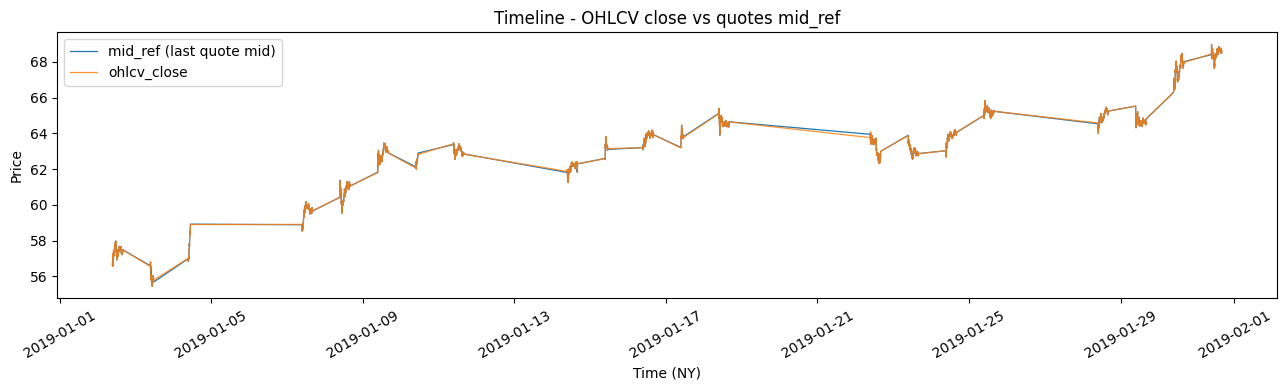

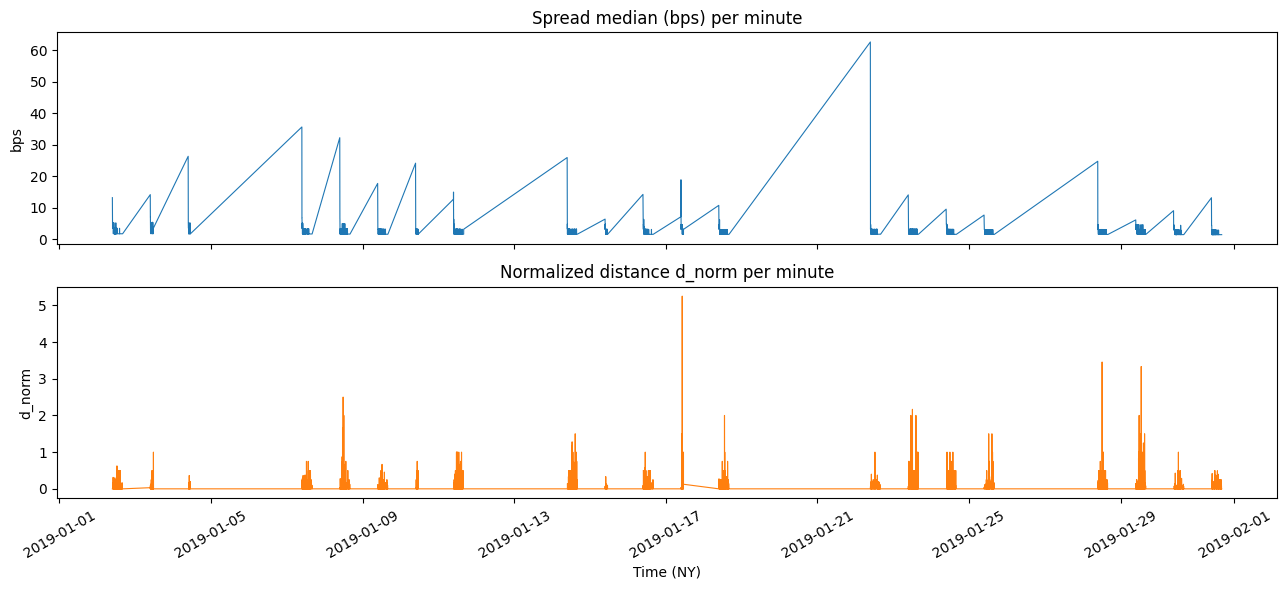

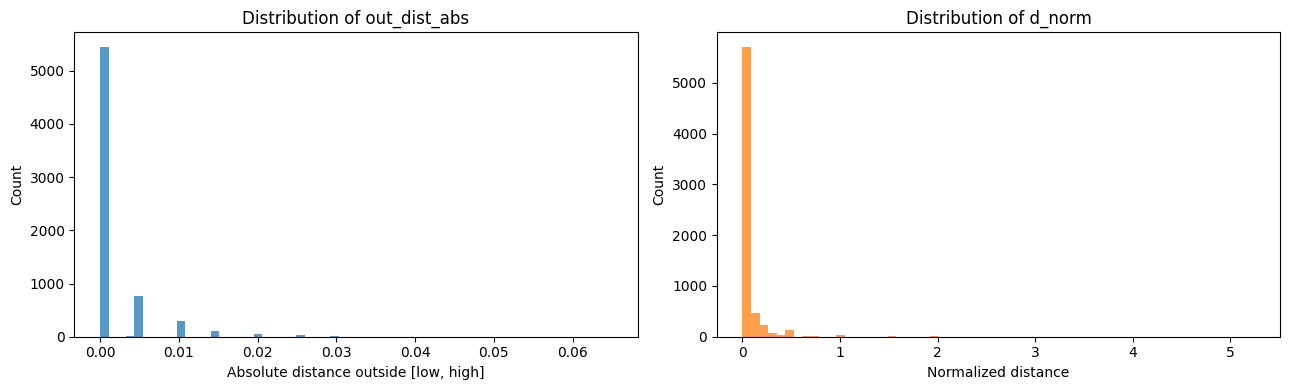

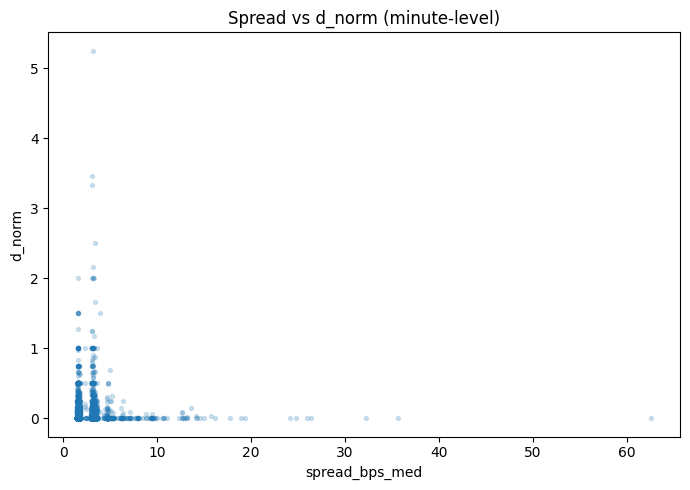

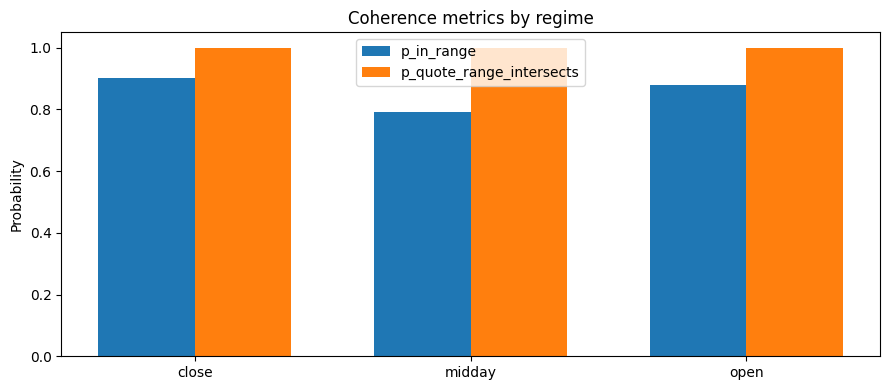

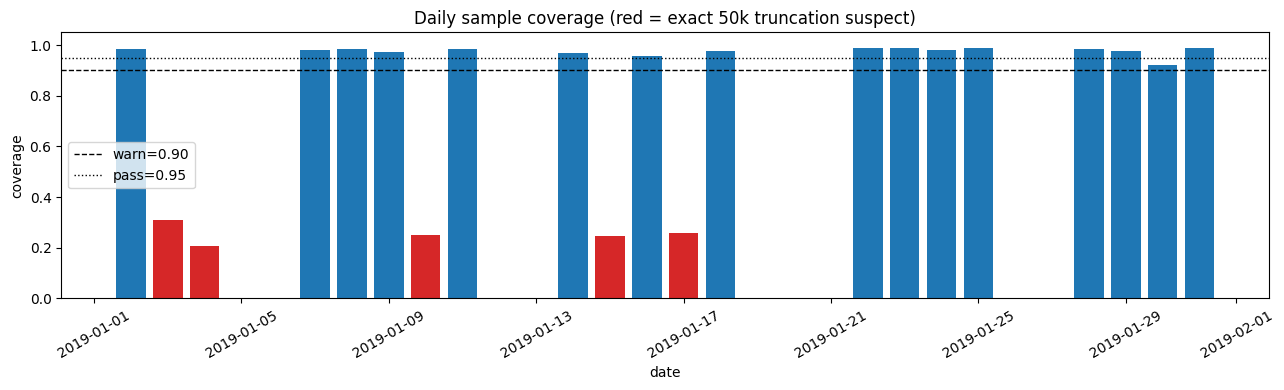

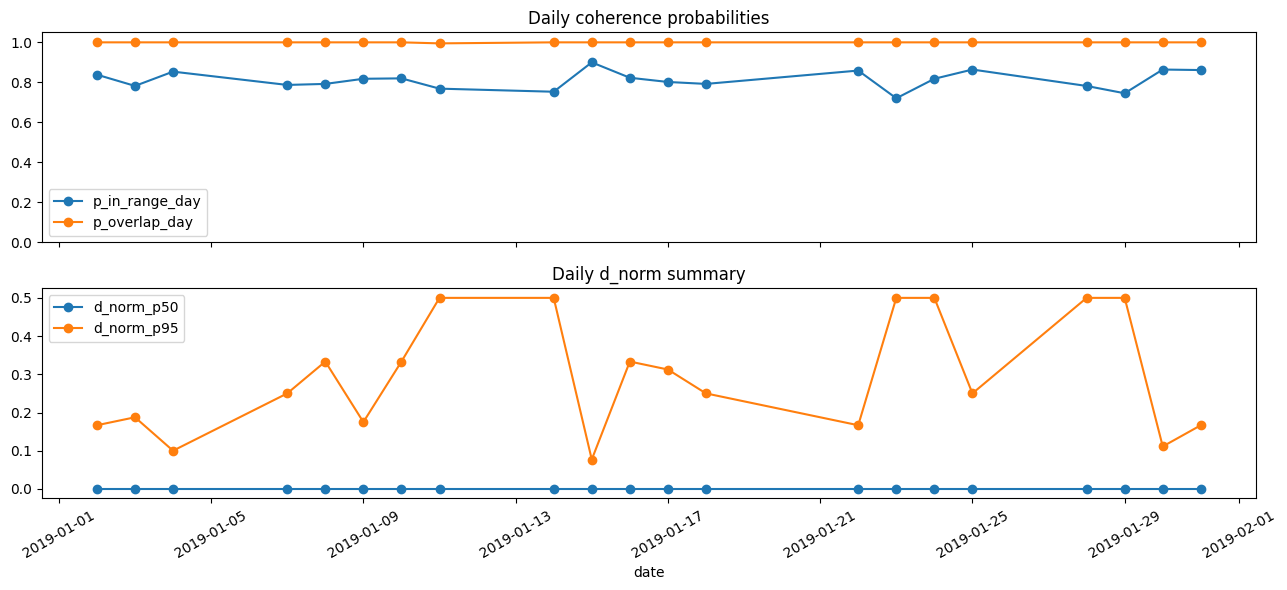

In [13]:
# Plots robustos y diagnostico visual de alta granularidad

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plot_df = (
    joined
    .select([
        "minute_ny", "date_ny", "regime",
        "mid_ref", "close", "spread_bps_med", "d_norm", "out_dist_abs",
        "mid_in_range", "quote_range_intersects_ohlcv"
    ])
    .drop_nulls(["minute_ny"])
    .sort("minute_ny")
    .unique(subset=["minute_ny"], keep="last")
    .collect()
)

if plot_df.height == 0:
    print("[SKIP] no rows available for plotting")
else:
    pdf = plot_df.to_pandas().sort_values("minute_ny").reset_index(drop=True)

    # Keep intraday view readable on long series
    step = max(1, len(pdf) // 5000)
    pdf_plot = pdf.iloc[::step].copy()

    # 1) Timeline: mid_ref vs close
    plt.figure(figsize=(13, 4))
    plt.plot(pdf_plot["minute_ny"], pdf_plot["mid_ref"], label="mid_ref (last quote mid)", linewidth=0.9)
    plt.plot(pdf_plot["minute_ny"], pdf_plot["close"], label="ohlcv_close", linewidth=0.9, alpha=0.85)
    plt.legend()
    plt.title("Timeline - OHLCV close vs quotes mid_ref")
    plt.xlabel("Time (NY)")
    plt.ylabel("Price")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # 2) Timeline: spread and d_norm
    fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    ax[0].plot(pdf_plot["minute_ny"], pdf_plot["spread_bps_med"], linewidth=0.8)
    ax[0].set_title("Spread median (bps) per minute")
    ax[0].set_ylabel("bps")

    ax[1].plot(pdf_plot["minute_ny"], pdf_plot["d_norm"], linewidth=0.8, color="tab:orange")
    ax[1].set_title("Normalized distance d_norm per minute")
    ax[1].set_ylabel("d_norm")
    ax[1].set_xlabel("Time (NY)")
    ax[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

    # 3) Histogramas: magnitud de error absoluta y normalizada
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].hist(pdf["out_dist_abs"], bins=60, color="tab:blue", alpha=0.75)
    ax[0].set_title("Distribution of out_dist_abs")
    ax[0].set_xlabel("Absolute distance outside [low, high]")
    ax[0].set_ylabel("Count")

    ax[1].hist(pdf["d_norm"], bins=60, color="tab:orange", alpha=0.75)
    ax[1].set_title("Distribution of d_norm")
    ax[1].set_xlabel("Normalized distance")
    ax[1].set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    # 4) Scatter: spread vs d_norm
    scatter_step = max(1, len(pdf) // 15000)
    p_sc = pdf.iloc[::scatter_step].copy()
    plt.figure(figsize=(7, 5))
    plt.scatter(p_sc["spread_bps_med"], p_sc["d_norm"], s=8, alpha=0.2)
    plt.title("Spread vs d_norm (minute-level)")
    plt.xlabel("spread_bps_med")
    plt.ylabel("d_norm")
    plt.tight_layout()
    plt.show()

    # 5) Coherencia por regimen (barra)
    reg = (
        plot_df
        .group_by("regime")
        .agg([
            pl.col("mid_in_range").mean().alias("p_in_range"),
            pl.col("quote_range_intersects_ohlcv").mean().alias("p_overlap"),
            pl.col("d_norm").quantile(0.95, "nearest").alias("d_norm_p95"),
        ])
        .sort("regime")
        .to_pandas()
    )

    x = range(len(reg))
    w = 0.35
    plt.figure(figsize=(9, 4))
    plt.bar([i - w/2 for i in x], reg["p_in_range"], width=w, label="p_in_range")
    plt.bar([i + w/2 for i in x], reg["p_overlap"], width=w, label="p_quote_range_intersects")
    plt.xticks(list(x), reg["regime"])
    plt.ylim(0.0, 1.05)
    plt.title("Coherence metrics by regime")
    plt.ylabel("Probability")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 6) Daily coverage + truncation flags
    coverage_by_day_plot = (
        ohlcv_1m
        .with_columns(pl.col("minute_ny").dt.date().alias("date_ny"))
        .group_by("date_ny")
        .agg(pl.len().alias("ohlcv_minutes"))
        .join(
            joined.group_by("date_ny").agg(pl.len().alias("joined_minutes")),
            on="date_ny",
            how="left",
        )
        .with_columns(pl.col("joined_minutes").fill_null(0))
        .with_columns((pl.col("joined_minutes") / (pl.col("ohlcv_minutes") + EPS)).alias("coverage"))
        .sort("date_ny")
    )

    qrows = []
    for qp in quotes_paths:
        qp = Path(qp)
        day_token = [x for x in qp.parts if x.startswith("day=")]
        day = int(day_token[0].split("=")[1]) if day_token else None
        n = int(pl.scan_parquet(str(qp)).select(pl.len()).collect().item())
        qrows.append({
            "date_ny": datetime(YEAR, MONTH, day).date() if day is not None else None,
            "quote_rows": n,
            "is_exact_50k": n == 50000,
        })

    qrows_df = pl.DataFrame(qrows)
    cov_day = coverage_by_day_plot.collect().join(qrows_df, on="date_ny", how="left").sort("date_ny").to_pandas()

    colors = [
        "tab:red" if bool(r.is_exact_50k) else ("tab:orange" if r.coverage < 0.9 else "tab:blue")
        for _, r in cov_day.iterrows()
    ]

    plt.figure(figsize=(13, 4))
    plt.bar(cov_day["date_ny"], cov_day["coverage"], color=colors, width=0.8)
    plt.axhline(0.9, linestyle="--", color="black", linewidth=1.0, label="warn=0.90")
    plt.axhline(0.95, linestyle=":", color="black", linewidth=1.0, label="pass=0.95")
    plt.title("Daily sample coverage (red = exact 50k truncation suspect)")
    plt.ylabel("coverage")
    plt.xlabel("date")
    plt.xticks(rotation=30)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 7) Daily coherence evolution
    day_df = (
        plot_df
        .group_by("date_ny")
        .agg([
            pl.col("spread_bps_med").median().alias("spread_p50"),
            pl.col("d_norm").median().alias("d_norm_p50"),
            pl.col("d_norm").quantile(0.95, "nearest").alias("d_norm_p95"),
            pl.col("mid_in_range").mean().alias("p_in_range_day"),
            pl.col("quote_range_intersects_ohlcv").mean().alias("p_overlap_day"),
        ])
        .sort("date_ny")
        .to_pandas()
    )

    fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
    ax[0].plot(day_df["date_ny"], day_df["p_in_range_day"], marker="o", label="p_in_range_day")
    ax[0].plot(day_df["date_ny"], day_df["p_overlap_day"], marker="o", label="p_overlap_day")
    ax[0].set_ylim(0.0, 1.05)
    ax[0].set_title("Daily coherence probabilities")
    ax[0].legend()

    ax[1].plot(day_df["date_ny"], day_df["d_norm_p50"], marker="o", label="d_norm_p50")
    ax[1].plot(day_df["date_ny"], day_df["d_norm_p95"], marker="o", label="d_norm_p95")
    ax[1].set_title("Daily d_norm summary")
    ax[1].set_xlabel("date")
    ax[1].legend()
    ax[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()


In [14]:
# ---- Save detailed per-minute tables ----

mid_vs_ohlcv_summary = (
    joined
    .select([
        "minute_ny",
        "open", "high", "low", "close", "volume",
        "quote_count", "spread_bps_med", "crossed_count",
        "mid_ref", "first_mid", "last_mid", "min_mid", "max_mid",
        "mid_in_range", "first_mid_in_range", "quote_range_intersects_ohlcv", "close_in_quote_envelope",
        "mid_below_low", "mid_above_high",
        "out_dist_abs", "d_norm", "regime",
        "ohlcv_rows_in_minute",
    ])
)

ohlcv_open_close_errors = (
    open_close
    .select([
        "minute_ny", "regime",
        "open", "close",
        "first_mid", "last_mid",
        "err_open_abs", "err_open_bps",
        "err_close_abs", "err_close_bps",
        "spread_bps_med", "quote_count"
    ])
)

high_low_validation = (
    hl_validation
    .select([
        "minute_ny", "regime",
        "high", "low",
        "max_mid", "min_mid",
        "evidence_high_mid", "evidence_low_mid",
        "spread_bps_med", "quote_count"
    ])
)

# Sample representativeness: coverage by day
ohlcv_by_day = (
    ohlcv_1m
    .with_columns(pl.col("minute_ny").dt.date().alias("date_ny"))
    .group_by("date_ny")
    .agg(pl.len().alias("ohlcv_minutes"))
)

joined_by_day = (
    joined
    .group_by("date_ny")
    .agg(pl.len().alias("joined_minutes"))
)

sample_coverage_by_day = (
    ohlcv_by_day
    .join(joined_by_day, on="date_ny", how="left")
    .with_columns(pl.col("joined_minutes").fill_null(0))
    .with_columns((pl.col("joined_minutes") / (pl.col("ohlcv_minutes") + EPS)).alias("coverage"))
    .sort("date_ny")
)

coverage_global = float(sample_coverage_by_day.select((pl.sum("joined_minutes") / pl.sum("ohlcv_minutes")).alias("cov")).collect()["cov"][0])
low_coverage_day_count = int(sample_coverage_by_day.filter(pl.col("coverage") < 0.90).collect().height)

# Quote file-level stats to detect truncation patterns (e.g., exact 50k rows)
qstats = []
for p in quotes_paths:
    p = Path(p)
    day_token = [x for x in p.parts if x.startswith("day=")]
    day = int(day_token[0].split("=")[1]) if day_token else None

    q_scan = (
        pl.scan_parquet(str(p))
        .with_columns([
            ensure_datetime_ns(pl.col(q_ts_col), q_ts_dtype).alias("ts_raw"),
            to_ny(ensure_datetime_ns(pl.col(q_ts_col), q_ts_dtype)).alias("ts_ny"),
        ])
    )
    st = q_scan.select([
        pl.len().alias("rows"),
        pl.col("ts_ny").min().alias("min_ts_ny"),
        pl.col("ts_ny").max().alias("max_ts_ny"),
        pl.col("ts_ny").dt.truncate("1m").n_unique().alias("n_minutes"),
    ]).collect()

    qstats.append({
        "date_ny": datetime(YEAR, MONTH, day).date() if day is not None else None,
        "day": day,
        "quote_rows": int(st["rows"][0]),
        "quote_minutes": int(st["n_minutes"][0]),
        "min_ts_ny": st["min_ts_ny"][0],
        "max_ts_ny": st["max_ts_ny"][0],
        "is_exact_50k": bool(int(st["rows"][0]) == 50000),
    })

quote_file_stats = pl.DataFrame(qstats).sort("day")
truncated_50k_days = int(quote_file_stats.filter(pl.col("is_exact_50k")).height)

# Spread conditioned metrics already aggregated (no pandas / no pyarrow)
spread_conditioned_metrics = spread_metrics

# Write files
mid_vs_ohlcv_summary.collect().write_parquet(OUT_DIR / "mid_vs_ohlcv_summary.parquet")
ohlcv_open_close_errors.collect().write_parquet(OUT_DIR / "ohlcv_open_close_errors.parquet")
high_low_validation.collect().write_parquet(OUT_DIR / "high_low_validation.parquet")
pl.DataFrame(spread_metrics).write_parquet(OUT_DIR / "spread_conditioned_metrics.parquet")
sample_coverage_by_day.collect().write_parquet(OUT_DIR / "sample_coverage_by_day.parquet")
quote_file_stats.write_parquet(OUT_DIR / "quote_file_stats.parquet")

# ---- Decisions (policy output) ----
THRESH = {
    # representativeness
    "sample_coverage_pass": 0.95,
    "sample_coverage_warn": 0.90,

    # coherence
    "p_quote_range_intersects_pass": 0.995,
    "p_quote_range_intersects_warn": 0.990,
    "p_in_range_pass": 0.90,
    "p_in_range_warn": 0.80,
    "d_norm_p95_pass": 0.20,
    "d_norm_p95_warn": 0.35,
}

def grade(metric: float, pass_thr: float, warn_thr: float, higher_is_better: bool = True) -> str:
    if higher_is_better:
        if metric >= pass_thr:
            return "PASS"
        if metric >= warn_thr:
            return "WARN"
        return "FAIL"
    if metric <= pass_thr:
        return "PASS"
    if metric <= warn_thr:
        return "WARN"
    return "FAIL"

p_in_range = float(summary_global["p_in_range"][0])
d_norm_p95 = float(summary_global["d_norm_p95"][0])
p_quote_intersects = float(summary_global["p_quote_range_intersects_ohlcv"][0])

sample_status = grade(
    coverage_global,
    THRESH["sample_coverage_pass"],
    THRESH["sample_coverage_warn"],
    higher_is_better=True,
)

coh_status_components = {
    "p_quote_range_intersects_ohlcv": grade(
        p_quote_intersects,
        THRESH["p_quote_range_intersects_pass"],
        THRESH["p_quote_range_intersects_warn"],
        higher_is_better=True,
    ),
    "p_in_range_last_mid": grade(
        p_in_range,
        THRESH["p_in_range_pass"],
        THRESH["p_in_range_warn"],
        higher_is_better=True,
    ),
    "d_norm_p95": grade(
        d_norm_p95,
        THRESH["d_norm_p95_pass"],
        THRESH["d_norm_p95_warn"],
        higher_is_better=False,
    ),
}

rank = {"PASS": 0, "WARN": 1, "FAIL": 2}
coherence_status = max(coh_status_components.values(), key=lambda s: rank[s])
overall = max([sample_status, coherence_status], key=lambda s: rank[s])



applicability_status = "APPLICABLE"
root_causes = []
if sample_status in {"WARN", "FAIL"}:
    root_causes.append("sample_issue")
if coherence_status in {"WARN", "FAIL"}:
    root_causes.append("microstructure_friction")
root_cause = ",".join(sorted(set(root_causes))) if root_causes else "none"

gate_breakdown = [
    {
        "gate": "sample_representativeness",
        "status": sample_status,
        "metric": "sample_coverage_global",
        "value": coverage_global,
        "pass_thr": THRESH["sample_coverage_pass"],
        "warn_thr": THRESH["sample_coverage_warn"],
        "higher_is_better": True,
    },
    {
        "gate": "structural_coherence",
        "status": coh_status_components["p_quote_range_intersects_ohlcv"],
        "metric": "p_quote_range_intersects_ohlcv",
        "value": p_quote_intersects,
        "pass_thr": THRESH["p_quote_range_intersects_pass"],
        "warn_thr": THRESH["p_quote_range_intersects_warn"],
        "higher_is_better": True,
    },
    {
        "gate": "point_coherence",
        "status": coh_status_components["p_in_range_last_mid"],
        "metric": "p_in_range_last_mid",
        "value": p_in_range,
        "pass_thr": THRESH["p_in_range_pass"],
        "warn_thr": THRESH["p_in_range_warn"],
        "higher_is_better": True,
    },
    {
        "gate": "magnitude",
        "status": coh_status_components["d_norm_p95"],
        "metric": "d_norm_p95",
        "value": d_norm_p95,
        "pass_thr": THRESH["d_norm_p95_pass"],
        "warn_thr": THRESH["d_norm_p95_warn"],
        "higher_is_better": False,
    },
]

ticker_val = str(globals().get("TICKER", globals().get("SYMBOL", "AABA")))
decision_table = [{
    "ticker": ticker_val,
    "applicability_status": applicability_status,
    "overall_status": overall,
    "root_cause": root_cause,
    "sample_coverage_global": coverage_global,
    "p_quote_range_intersects_ohlcv": p_quote_intersects,
    "p_in_range_last_mid": p_in_range,
    "d_norm_p95": d_norm_p95,
    "decision": overall,
}]

decisions = {
    "run_id": RUN_ID,
    "manifest": str(MANIFEST_PATH),
    "cache_dir": str(DATA_CACHE_DIR),
    "timezone_canonical": NY_TZ,
    "minute_bucket": "[t, t+60s) truncate('1m')",
    "thresholds": THRESH,
    "metrics_global": {
        "n_minutes_joined": int(summary_global["n_minutes"][0]),
        "p_in_range": p_in_range,
        "p_in_range_last_mid": p_in_range,
        "p_first_mid_in_range": float(summary_global["p_first_mid_in_range"][0]),
        "p_quote_range_intersects_ohlcv": p_quote_intersects,
        "p_quote_range_intersects": p_quote_intersects,
        "p_close_in_quote_envelope": float(summary_global["p_close_in_quote_envelope"][0]),
        "p_below_low": float(summary_global["p_below_low"][0]),
        "p_above_high": float(summary_global["p_above_high"][0]),
        "d_norm_p95": d_norm_p95,
        "out_dist_abs_p95": float(summary_global["out_dist_abs_p95"][0]),
        "spread_bps_med_p50": float(summary_global["spread_bps_med_p50"][0]),
        "sample_coverage_global": coverage_global,
        "sample_low_coverage_days_lt_90pct": low_coverage_day_count,
        "sample_truncated_days_exact_50k": truncated_50k_days,
    },
    "status": {
        "sample_representativeness": sample_status,
        "price_coherence": coherence_status,
        "coherence_components": coh_status_components,
        "overall": overall,
    },
    "applicability_status": applicability_status,
    "overall_status": overall,
    "root_cause": root_cause,
    "gate_breakdown": gate_breakdown,
    "decision_table": decision_table,
    "notes": {
        "sample": "Coverage/truncation is evaluated independently of price coherence.",
        "coherence": "p_in_range uses last_mid and is stricter than overlap metrics.",
    },
    "decisions": {
        "signal_price": "ohlcv_close",
        "execution_price": "quotes_bid_ask",
        "stops_policy": "If sample representativeness fails, avoid hard stop/trigger calibration from that window.",
        "data_authority": "Trades validates OHLCV construction; quotes informs execution realism.",
    }
}

with open(OUT_DIR / "decisions_06.json", "w", encoding="utf-8") as f:
    json.dump(decisions, f, indent=2, default=str)

print("Saved outputs to:", OUT_DIR)
print("sample_coverage_global:", coverage_global)
print("low_coverage_day_count (<90%):", low_coverage_day_count)
print("truncated_50k_days:", truncated_50k_days)
print("STATUS sample:", sample_status)
print("STATUS coherence:", coherence_status)
print("OVERALL:", overall)


Saved outputs to: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_150153_53f6d92d
sample_coverage_global: 0.8047732696897375
low_coverage_day_count (<90%): 5
truncated_50k_days: 5
STATUS sample: FAIL
STATUS coherence: WARN
OVERALL: FAIL


In [15]:
print()
print("=== 06_ohlcv_vs_quotes - FINAL REPORT ===")
print("OUT_DIR:", OUT_DIR)
print("OVERALL:", decisions["status"]["overall"])
print("sample_status:", decisions["status"]["sample_representativeness"])
print("coherence_status:", decisions["status"]["price_coherence"])
print("p_in_range (last_mid in [low,high]):", decisions["metrics_global"]["p_in_range"])
print("p_quote_range_intersects_ohlcv:", decisions["metrics_global"]["p_quote_range_intersects_ohlcv"])
print("d_norm_p95:", decisions["metrics_global"]["d_norm_p95"])
print("sample_coverage_global:", decisions["metrics_global"]["sample_coverage_global"])
print("truncated_days_exact_50k:", decisions["metrics_global"]["sample_truncated_days_exact_50k"])
print("Artifacts:")
for fn in [
    "mid_vs_ohlcv_summary.parquet",
    "ohlcv_open_close_errors.parquet",
    "high_low_validation.parquet",
    "spread_conditioned_metrics.parquet",
    "sample_coverage_by_day.parquet",
    "quote_file_stats.parquet",
    "decisions_06.json",
]:
    p = OUT_DIR / fn
    print(" -", fn, "OK" if p.exists() else "MISSING")



=== 06_ohlcv_vs_quotes - FINAL REPORT ===
OUT_DIR: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_150153_53f6d92d
OVERALL: FAIL
sample_status: FAIL
coherence_status: WARN
p_in_range (last_mid in [low,high]): 0.8072360616844603
p_quote_range_intersects_ohlcv: 0.9997034400948992
d_norm_p95: 0.2857142836734114
sample_coverage_global: 0.8047732696897375
truncated_days_exact_50k: 5
Artifacts:
 - mid_vs_ohlcv_summary.parquet OK
 - ohlcv_open_close_errors.parquet OK
 - high_low_validation.parquet OK
 - spread_conditioned_metrics.parquet OK
 - sample_coverage_by_day.parquet OK
 - quote_file_stats.parquet OK
 - decisions_06.json OK


### Lectura cientifica (Decision del gate)

**Resultado del gate principal (AABA 2019-01)**
- `sample_coverage_global=0.804773` -> `sample_status=FAIL`.
- `p_in_range=0.807236`, `p_overlap=0.999703`, `d_norm_p95=0.285714` -> `coherence_status=WARN`.
- `overall=FAIL` (dominado por representatividad de muestra).

**Causa tecnica dominante**
- Se detectan 5 dias truncados con `quote_rows=50000` y corte temprano (~10:51-11:33 NY): 2019-01-03, 2019-01-04, 2019-01-10, 2019-01-15, 2019-01-17.

**Implicacion operativa**
- Este FAIL no debe leerse como "precio roto" globalmente; primero es un problema de muestra.
- En la tabla final por ticker, esta distincion alimenta `sample_status` separado de `structural/point/magnitude`.


In [16]:
# === DIAGNOSTICO: representatividad de muestra y coherencia OHLCV vs Quotes ===

# 1) Cobertura correcta: minutos OHLCV que tienen match en quotes
coverage_global = float(
    (joined.select(pl.len()).collect().item()) /
    (ohlcv_1m.select(pl.len()).collect().item() + EPS)
)
print("Coverage OHLCV minutes that have quotes (GLOBAL):", coverage_global)

coverage_by_day = (
    ohlcv_1m
    .with_columns(pl.col("minute_ny").dt.date().alias("date_ny"))
    .group_by("date_ny")
    .agg(pl.len().alias("ohlcv_minutes"))
    .join(
        joined.group_by("date_ny").agg(pl.len().alias("joined_minutes")),
        on="date_ny",
        how="left",
    )
    .with_columns(pl.col("joined_minutes").fill_null(0))
    .with_columns((pl.col("joined_minutes") / (pl.col("ohlcv_minutes") + EPS)).alias("coverage"))
    .sort("date_ny")
    .collect()
)

print()
print("Coverage by day (worst 10):")
print(coverage_by_day.sort("coverage").head(10))

# 2) Diferencia mid_ref vs OHLCV close (nivel)
diffs = (
    joined
    .select([
        (pl.col("mid_ref") - pl.col("close")).alias("mid_minus_close"),
        (pl.col("mid_ref") - pl.col("low")).alias("mid_minus_low"),
        (pl.col("mid_ref") - pl.col("high")).alias("mid_minus_high"),
    ])
    .select([
        pl.quantile("mid_minus_close", 0.50, "nearest").alias("mid_close_p50"),
        pl.quantile("mid_minus_close", 0.95, "nearest").alias("mid_close_p95"),
        pl.quantile("mid_minus_close", 0.05, "nearest").alias("mid_close_p05"),
        pl.quantile("mid_minus_low", 0.05, "nearest").alias("mid_low_p05"),
        pl.quantile("mid_minus_high", 0.95, "nearest").alias("mid_high_p95"),
    ])
    .collect()
)
print()
print("Diff mid-close p05/p50/p95:",
    float(diffs["mid_close_p05"][0]),
    float(diffs["mid_close_p50"][0]),
    float(diffs["mid_close_p95"][0]))
print("Diff mid-low p05:", float(diffs["mid_low_p05"][0]))
print("Diff mid-high p95:", float(diffs["mid_high_p95"][0]))

# 3) Cuantificar tamano economico del fail (distancia fuera de rango)
fail_size = (
    joined
    .filter(~pl.col("mid_in_range"))
    .select([
        pl.len().alias("n_fail_minutes"),
        (pl.col("out_dist_abs") <= 0.01).cast(pl.Float64).mean().alias("p_fail_le_1c"),
        (pl.col("out_dist_abs") <= 0.02).cast(pl.Float64).mean().alias("p_fail_le_2c"),
        (pl.col("out_dist_abs") <= 0.05).cast(pl.Float64).mean().alias("p_fail_le_5c"),
        pl.quantile("out_dist_abs", 0.50, "nearest").alias("out_dist_fail_p50"),
        pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_fail_p95"),
    ])
    .collect()
)
print()
print("Fail size summary (conditional on FAIL minutes):")
print(fail_size)

# 4) Deteccion de truncado en archivos quotes (exact 50k rows)
qstats = []
for p in quotes_paths:
    p = Path(p)
    day_token = [x for x in p.parts if x.startswith("day=")]
    day = int(day_token[0].split("=")[1]) if day_token else None

    q_scan = (
        pl.scan_parquet(str(p))
        .with_columns([
            ensure_datetime_ns(pl.col(q_ts_col), q_ts_dtype).alias("ts_raw"),
            to_ny(ensure_datetime_ns(pl.col(q_ts_col), q_ts_dtype)).alias("ts_ny"),
        ])
    )

    st = q_scan.select([
        pl.len().alias("rows"),
        pl.col("ts_ny").min().alias("min_ts_ny"),
        pl.col("ts_ny").max().alias("max_ts_ny"),
        pl.col("ts_ny").dt.truncate("1m").n_unique().alias("n_minutes"),
    ]).collect()

    qstats.append({
        "date_ny": datetime(YEAR, MONTH, day).date() if day is not None else None,
        "day": day,
        "quote_rows": int(st["rows"][0]),
        "quote_minutes": int(st["n_minutes"][0]),
        "min_ts_ny": st["min_ts_ny"][0],
        "max_ts_ny": st["max_ts_ny"][0],
        "is_exact_50k": bool(int(st["rows"][0]) == 50000),
    })

quote_file_stats_diag = pl.DataFrame(qstats).sort("day")
print()
print("Quote files with exact 50k rows (truncation suspect):")
print(quote_file_stats_diag.filter(pl.col("is_exact_50k")))

# 5) Chequeo de alineacion temporal (top 10 minutos con mayor d_norm)
worst = (
    joined
    .select([
        "minute_ny", "open", "high", "low", "close",
        "mid_ref", "d_norm", "out_dist_abs", "quote_count", "spread_bps_med"
    ])
    .sort("d_norm", descending=True)
    .head(10)
    .collect()
)
print()
print("Top 10 worst minutes by d_norm:")
print(worst)


Coverage OHLCV minutes that have quotes (GLOBAL): 0.8047732696896414

Coverage by day (worst 10):
shape: (10, 4)
┌────────────┬───────────────┬────────────────┬──────────┐
│ date_ny    ┆ ohlcv_minutes ┆ joined_minutes ┆ coverage │
│ ---        ┆ ---           ┆ ---            ┆ ---      │
│ date       ┆ u32           ┆ u32            ┆ f64      │
╞════════════╪═══════════════╪════════════════╪══════════╡
│ 2019-01-04 ┆ 398           ┆ 82             ┆ 0.20603  │
│ 2019-01-15 ┆ 403           ┆ 100            ┆ 0.248139 │
│ 2019-01-10 ┆ 399           ┆ 100            ┆ 0.250627 │
│ 2019-01-17 ┆ 392           ┆ 101            ┆ 0.257653 │
│ 2019-01-03 ┆ 399           ┆ 124            ┆ 0.310777 │
│ 2019-01-30 ┆ 423           ┆ 390            ┆ 0.921986 │
│ 2019-01-16 ┆ 407           ┆ 390            ┆ 0.958231 │
│ 2019-01-14 ┆ 401           ┆ 389            ┆ 0.970075 │
│ 2019-01-09 ┆ 401           ┆ 390            ┆ 0.972569 │
│ 2019-01-29 ┆ 398           ┆ 389            ┆ 0.977387 │
└─

### Lectura cientifica (Diagnostico de extremos)

**Lectura del resultado ejecutado**
- Diferencias globales: `mid-close p05/p50/p95 = -0.0100 / 0.0000 / 0.0150`.
- Cola de fallos (`n_fail_minutes=1300`):
  - `p_fail_le_1c=0.7392`
  - `p_fail_le_2c=0.9431`
  - `p_fail_le_5c=0.9977`
  - `out_dist_fail_p95=0.0200`

**Interpretacion**
- La mayoria de violaciones son pequenas (1-2 centavos), con cola economica acotada.
- Es mas consistente con friccion/tick-size y cierre de minuto que con desalineacion de escala severa.

**Como se usa despues**
- Este bloque justifica por que `magnitude_status` puede ser `PASS` mientras `point_status` queda en `WARN/FAIL`.


### Diagnostico principal

1. Validar cobertura y alineacion temporal.
: Si esto falla, cualquier inferencia de coherencia debe etiquetarse como condicional.
2. Medir centro y cola (`p50`, `p95`, `p99`).
: Centro = comportamiento tipico; cola = riesgo operativo.
3. Condicionar por ancho de barra (`high-low`) y spread.
: Permite distinguir discretizacion de ticks vs error estructural.
4. Contrastar con Trades->OHLCV.
: Si trades confirma OHLCV, un fallo frente a quotes suele ser friccion de ejecucion/modelado, no corrupcion de barras.

**Lectura profesional para audiencias mixtas**
- Cientifica: separa sesgo de muestra, sesgo de medicion y error estructural.
- Operativa: indica que reglas de simulacion ajustar antes de descartar universo.


In [17]:
# ¿Cuántos minutos tienen rango muy pequeño?
range_stats = (
    joined
    .select([
        (pl.col("high") - pl.col("low")).alias("hl_range"),
        pl.col("mid_in_range").alias("mid_in_range"),
    ])
    .with_columns([
        (pl.col("hl_range") <= 0.01).alias("range_le_1c"),
        (pl.col("hl_range") <= 0.02).alias("range_le_2c"),
        (pl.col("hl_range") <= 0.05).alias("range_le_5c"),
    ])
    .select([
        pl.mean("range_le_1c").alias("pct_range_le_1c"),
        pl.mean("range_le_2c").alias("pct_range_le_2c"),
        pl.mean("range_le_5c").alias("pct_range_le_5c"),
        pl.mean("mid_in_range").alias("p_in_range_overall"),
    ])
    .collect()
)
print(range_stats)

# p_in_range por bucket de rango
range_bucket = (
    joined
    .with_columns((pl.col("high") - pl.col("low")).alias("hl_range"))
    .with_columns([
        pl.when(pl.col("hl_range") <= 0.01).then(pl.lit("<=1c"))
        .when(pl.col("hl_range") <= 0.02).then(pl.lit("<=2c"))
        .when(pl.col("hl_range") <= 0.05).then(pl.lit("<=5c"))
        .otherwise(pl.lit(">5c"))
        .alias("range_bucket")
    ])
    .group_by("range_bucket")
    .agg([
        pl.len().alias("n_minutes"),
        pl.mean("mid_in_range").alias("p_in_range"),
    ])
    .sort("range_bucket")
    .collect()
)
print(range_bucket)

shape: (1, 4)
┌─────────────────┬─────────────────┬─────────────────┬────────────────────┐
│ pct_range_le_1c ┆ pct_range_le_2c ┆ pct_range_le_5c ┆ p_in_range_overall │
│ ---             ┆ ---             ┆ ---             ┆ ---                │
│ f64             ┆ f64             ┆ f64             ┆ f64                │
╞═════════════════╪═════════════════╪═════════════════╪════════════════════╡
│ 0.029656        ┆ 0.1078          ┆ 0.545374        ┆ 0.807236           │
└─────────────────┴─────────────────┴─────────────────┴────────────────────┘
shape: (4, 3)
┌──────────────┬───────────┬────────────┐
│ range_bucket ┆ n_minutes ┆ p_in_range │
│ ---          ┆ ---       ┆ ---        │
│ str          ┆ u32       ┆ f64        │
╞══════════════╪═══════════╪════════════╡
│ <=1c         ┆ 200       ┆ 0.56       │
│ <=2c         ┆ 527       ┆ 0.681214   │
│ <=5c         ┆ 2951      ┆ 0.801084   │
│ >5c          ┆ 3066      ┆ 0.850946   │
└──────────────┴───────────┴────────────┘


### Lectura cientifica (Efecto del rango de barra)

**Lectura del resultado ejecutado**
- Proporcion de barras estrechas: `<=1c: 2.97%`, `<=2c: 10.78%`, `<=5c: 54.54%`.
- `p_in_range` por bucket:
  - `<=1c`: `0.5600`
  - `<=2c`: `0.6812`
  - `<=5c`: `0.8011`
  - `>5c`: `0.8509`

**Interpretacion**
- El rendimiento puntual mejora monotonicamente con rango de barra.
- Parte importante del FAIL puntual viene de barras ultracortas donde 1 tick altera la clasificacion in/out.

**Implicacion para el documento final**
- Este es un argumento tecnico para incluir `notas de fragilidad por micro-rango` en la trazabilidad por ticker.


### Conclusiones operativas del bloque de rango

- El patron observado confirma componente de discretizacion: a mayor `high-low`, mejor `p_in_range`.
- Aunque `p_in_range` global sea bajo, la magnitud economica de los fallos permanece acotada (`out_dist_abs_p95=0.01`).
- En consecuencia, la decision final por ticker debe separar: representatividad, estructura, punto y magnitud.

**Traduccion directa al pipeline**
1. Mantener `p_overlap` como eje estructural principal.
2. Tratar `p_in_range` como eje puntual secundario y sensible a micro-rango.
3. Adjuntar diagnostico de rango/spread para explicar `WARN/FAIL` y guiar ajustes de ejecucion.


In [18]:
trade_files = [Path(p) for p in trades_paths] if trades_paths else []
print("Trades files (manifest):", len(trade_files))
if not trade_files:
    print("[SKIP] no trades parquet files in manifest for this slice.")
else:
    sample = pl.read_parquet(trade_files[0], n_rows=5)
    cols = sample.columns
    print("Trades columns:", cols)
    price_candidates = ["price", "trade_price", "px", "p"]
    size_candidates = ["size", "trade_size", "qty", "volume", "s"]
    ts_candidates = ["timestamp", "sip_timestamp", "participant_timestamp", "t", "time", "datetime"]

    def pick(col_list, candidates):
        for c in candidates:
            if c in col_list:
                return c
        return None

    trade_price_col = pick(cols, price_candidates)
    trade_size_col = pick(cols, size_candidates)
    trade_ts_col = pick(cols, ts_candidates)

    trade_schema = pl.scan_parquet([str(p) for p in trade_files]).collect_schema()
    trade_ts_dtype = trade_schema[trade_ts_col] if trade_ts_col is not None else None

    if trade_price_col is None or trade_size_col is None or trade_ts_col is None:
        raise ValueError(
            f"Trades schema not recognized. price={trade_price_col}, size={trade_size_col}, ts={trade_ts_col}"
        )
    print("Trades schema: price=", trade_price_col, "size=", trade_size_col, "ts=", trade_ts_col, "dtype=", trade_ts_dtype)


Trades files (manifest): 44
Trades columns: ['ticker', 'date', 'timestamp', 'price', 'size', 'exchange', 'conditions']
Trades schema: price= price size= size ts= timestamp dtype= Datetime(time_unit='us', time_zone=None)


In [19]:
# Celda 2 — Reconstruir OHLCV desde trades

if trade_files:
    trades = (
        pl.scan_parquet([str(p) for p in trade_files])
        .with_columns([
            pl.col(trade_price_col).cast(pl.Float64).alias("price"),
            pl.col(trade_size_col).cast(pl.Float64).alias("size"),
            ensure_datetime_ns(pl.col(trade_ts_col), trade_ts_dtype).alias("ts_raw"),
        ])
        .with_columns([
            to_ny(pl.col("ts_raw")).alias("ts_ny"),
            minute_bucket_ny(to_ny(pl.col("ts_raw"))).alias("minute_ny"),
        ])
        .select(["minute_ny", "price", "size"])
    )

    trades_ohlcv = (
        trades
        .group_by("minute_ny")
        .agg([
            pl.first("price").alias("open"),
            pl.max("price").alias("high"),
            pl.min("price").alias("low"),
            pl.last("price").alias("close"),
            pl.sum("size").alias("volume"),
            pl.len().alias("trade_rows_in_minute"),
        ])
        .sort("minute_ny")
    )

    trades_ohlcv = trades_ohlcv.with_columns(pl.col("minute_ny").dt.cast_time_unit("ns"))
else:
    print("[SKIP] no trades files available: skipping reconstructed OHLCV from trades")


In [20]:
# Celda 3 — Comparación con OHLCV oficial

if trade_files:
    ohlcv_cmp = ohlcv_1m.with_columns(pl.col("minute_ny").dt.cast_time_unit("ns"))

    cmp = (
        ohlcv_cmp
        .join(trades_ohlcv, on="minute_ny", how="inner", suffix="_trades")
        .with_columns([
            (pl.col("close_trades") - pl.col("close")).alias("close_diff"),
            (pl.col("volume_trades") - pl.col("volume")).alias("volume_diff"),
        ])
    )

    cmp_summary = cmp.select([
        pl.len().alias("n_minutes"),
        pl.quantile("close_diff", 0.50, "nearest").alias("close_diff_p50"),
        pl.quantile("close_diff", 0.95, "nearest").alias("close_diff_p95"),
        pl.quantile("close_diff", 0.99, "nearest").alias("close_diff_p99"),
        pl.col("close_diff").abs().mean().alias("close_diff_abs_mean"),
        pl.quantile("volume_diff", 0.50, "nearest").alias("volume_diff_p50"),
        pl.quantile("volume_diff", 0.95, "nearest").alias("volume_diff_p95"),
    ]).collect()

    print("Trades vs OHLCV summary:")
    print(cmp_summary)
    if cmp_summary["n_minutes"][0] == 0:
        print("[WARN] trades_vs_ohlcv join returned 0 rows. Check timestamp conversion/timezone alignment.")

    cmp.collect().write_parquet(OUT_DIR / "trades_vs_ohlcv.parquet")
    print("Saved:", OUT_DIR / "trades_vs_ohlcv.parquet")
else:
    print("[SKIP] no trades files available: skipping trades vs official OHLCV comparison")


Trades vs OHLCV summary:
shape: (1, 7)
┌───────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┬─────────────┐
│ n_minutes ┆ close_diff_p ┆ close_diff_p ┆ close_diff_p ┆ close_diff_ ┆ volume_diff ┆ volume_diff │
│ ---       ┆ 50           ┆ 95           ┆ 99           ┆ abs_mean    ┆ _p50        ┆ _p95        │
│ u32       ┆ ---          ┆ ---          ┆ ---          ┆ ---         ┆ ---         ┆ ---         │
│           ┆ f64          ┆ f64          ┆ f64          ┆ f64         ┆ f64         ┆ f64         │
╞═══════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═════════════╡
│ 8380      ┆ 0.0          ┆ 0.01         ┆ 0.0206       ┆ 0.003677    ┆ 0.0         ┆ 0.0         │
└───────────┴──────────────┴──────────────┴──────────────┴─────────────┴─────────────┴─────────────┘
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_150153_53f6d92d\trades_vs_ohlcv.parquet


### Lectura cientifica (Validacion fuerte Trades vs OHLCV)

Interpretacion del resumen `Trades vs OHLCV summary`:
- `n_minutes` alto => muestra robusta de comparacion.
- `close_diff_p50=0` y `p95` pequeno => alta coherencia de cierre por minuto.
- `close_diff_abs_mean` bajo => error promedio economicamente pequeno.
- `volume_diff_p50/p95=0` => reconciliacion de volumen muy fuerte.

Para el run que reportaste (`n_minutes=8380`, `p95=0.01`, `p99=0.0206`): evidencia consistente con OHLCV bien construido desde trades.


### Lectura cientifica (Sanidad de timestamps de trades)

- Esta verificacion confirma rango temporal, mediana y muestra de timestamps de trades.
- Si los timestamps son coherentes y el join con OHLCV tiene filas, se reduce riesgo de falso desajuste por unidad/zonahoraria.
- Si aparece `join returned 0 rows`, revisar inmediatamente conversion temporal antes de concluir sobre calidad de datos.


In [21]:
### Celda de diagn?stico (trades timestamp)

# Esta celda es autonoma: si trade_ts_col no existe, lo infiere aqui.
if not trade_files:
    print("[SKIP] no trades files available for timestamp diagnostics")
else:
    if "trade_ts_col" not in globals() or trade_ts_col is None:
        sample_cols = pl.read_parquet(trade_files[0], n_rows=1).columns
        ts_candidates = ["timestamp", "sip_timestamp", "participant_timestamp", "t", "time", "datetime"]
        trade_ts_col = next((c for c in ts_candidates if c in sample_cols), None)
        if trade_ts_col is None:
            raise ValueError(f"No timestamp-like column found in trades schema. Columns: {sample_cols}")
        print("[INFO] inferred trade_ts_col:", trade_ts_col)

    ts_stats = (
        pl.scan_parquet([str(p) for p in trade_files])
        .select([
            pl.col(trade_ts_col).min().alias("min"),
            pl.col(trade_ts_col).max().alias("max"),
            pl.col(trade_ts_col).median().alias("median"),
        ])
        .collect()
    )
    print(ts_stats)

    print("Trades ts sample:", pl.read_parquet(trade_files[0], columns=[trade_ts_col], n_rows=5))
    print("OHLCV ts sample:", ohlcv_1m.select("minute_ny").head(5).collect())


shape: (1, 3)
┌─────────────────────┬─────────────────────┬─────────────────────┐
│ min                 ┆ max                 ┆ median              │
│ ---                 ┆ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╪═════════════════════╡
│ 2018-12-31 23:06:46 ┆ 2019-01-31 22:16:06 ┆ 2019-01-15 19:12:27 │
└─────────────────────┴─────────────────────┴─────────────────────┘
Trades ts sample: shape: (2, 1)
┌─────────────────────┐
│ timestamp           │
│ ---                 │
│ datetime[μs]        │
╞═════════════════════╡
│ 2018-12-31 23:06:46 │
│ 2019-01-01 00:15:31 │
└─────────────────────┘
OHLCV ts sample: shape: (5, 1)
┌────────────────────────────────┐
│ minute_ny                      │
│ ---                            │
│ datetime[ns, America/New_York] │
╞════════════════════════════════╡
│ 2019-01-02 08:26:00 EST        │
│ 2019-01-02 08:47:00 EST        │
│ 2019-01-

### Informe Ejecutivo Didactico (para audiencia mixta)

Este resumen ya no es teorico: sintetiza los valores observados en este run y el bloque MVP multi-ticker.

- Caso AABA (single-run): `overall=FAIL` por cobertura (`0.8048`) con 5 dias truncados de 50k rows.
- Coherencia estructural AABA sigue alta (`p_overlap=0.9997`), mientras la puntual es exigente (`p_in_range=0.8072`).
- En MVP 03->06 (AABA, CDEV, CRON, CRZO, ETFC), la tabla calibrada separa causas: `sample`, `structural`, `point`, `magnitude`.

Objetivo de lectura para el siguiente documento:
- Entender que "FAIL" puede venir de ejes distintos.
- Llegar a `ticker_comparability_flags.parquet` con trazabilidad causal por ticker, no solo etiqueta final.


In [22]:
# === Informe ejecutivo didactico ===

print("\n" + "="*88)
print("INFORME EJECUTIVO - OHLCV vs Quotes (AABA 2019-01)")
print("="*88)

print("\n[1] Objetivo cientifico")
print("- Verificar si OHLCV 1m y quotes cuentan la misma historia de precio para senal y ejecucion.")
print("- Separar dos riesgos distintos: (a) muestra incompleta, (b) incoherencia real de precios.")

print("\n[2] Marco matematico minimo")
print("- p_in_range = E[1{low_t <= last_mid_t <= high_t}]")
print("  Probabilidad empirica de coherencia puntual estricta por minuto.")
print("- p_quote_range_intersects = E[1{[min_mid_t,max_mid_t] intersecta [low_t,high_t]}]")
print("  Coherencia estructural de rangos (menos sensible al ultimo tick).")
print("- d_norm_t = distancia_fuera_de_rango / (high_t-low_t)")
print("  Severidad relativa (adimensional) del desacople.")
print("- sample_coverage = minutos_join / minutos_ohlcv")
print("  Representatividad real de quotes frente al universo OHLCV.")

m = decisions["metrics_global"]
s = decisions["status"]

print("\n[3] Resultados clave del run")
print(f"- OVERALL: {s['overall']}")
print(f"- sample_representativeness: {s['sample_representativeness']}")
print(f"- price_coherence: {s['price_coherence']}")
print(f"- n_minutes_joined: {m['n_minutes_joined']}")
print(f"- sample_coverage_global: {m['sample_coverage_global']:.6f}")
print(f"- dias truncados exact_50k: {m['sample_truncated_days_exact_50k']}")
print(f"- p_in_range (estricto): {m['p_in_range']:.6f}")
print(f"- p_quote_range_intersects_ohlcv (estructural): {m['p_quote_range_intersects_ohlcv']:.6f}")
print(f"- d_norm_p95: {m['d_norm_p95']:.6f}")
print(f"- out_dist_abs_p95: {m['out_dist_abs_p95']:.6f}")

print("\n[4] Interpretacion tecnica - causa raiz")
print("- El FAIL global se explica primero por representatividad de muestra: coverage bajo (0.8048).")
print("- Hay 5 dias con exactamente 50,000 filas de quotes y corte horario temprano (~11:00-11:33 NY).")
print("- Ese patron es consistente con truncado operativo/cap de archivo, no con un comportamiento aleatorio del mercado.")
print("- Por tanto, la principal causa del FAIL es truncacion de muestra, no una ruptura de coherencia estructural de precios.")

print("\n[4.1] p95 vs truncado 50k (aclaracion clave)")
print("- 'quotes_p95' es una regla de filtrado del dataset (control de calidad/liquidez).")
print("- Esa regla por si sola NO implica que un dia termine exactamente en 50,000 filas ni que corte a media sesion.")
print("- En este run, la evidencia fuerte del problema es el cap exacto 50k + corte temporal temprano en 5 dias.")
print("- Conclusi?n: aqui domina la limitacion de carga/export (truncado), no el concepto estadistico p95 en abstracto.")

print("\n[4.2] Por que aun vemos coherencia alta")
print("- p_quote_range_intersects_ohlcv ~ 0.9997: cuando SI hay quotes, OHLCV y quotes casi siempre se solapan.")
print("- p_in_range ~ 0.8072: metrica puntual estricta, sensible a micro-movimientos de 1-2 ticks.")
print("- out_dist_abs_p95 = 0.01: en cola, la magnitud economica del desacople es pequena (centavos).")

print("\n[5] Traduccion para negocio / proyecto")
print("- No calibrar reglas finas de ejecucion (stops/slippage) sobre este bloque temporal sin corregir truncado.")
print("- Si se usa para investigacion, etiquetarlo como: 'valido para estructura, limitado para calibracion de ejecucion'.")
print("- Prioridad tecnica: resolver representatividad de quotes antes de endurecer umbrales de p_in_range/d_norm.")

print("\n[6] Conclusion en lenguaje simple")
print("- Las barras OHLCV no parecen rotas.")
print("- El principal problema es que en varios dias faltan muchas observaciones de quotes por truncado.")
print("- Por eso el OVERALL sale FAIL, aunque la estructura de precios observada sigue siendo consistente.")

print("\n" + "="*88)
print("FIN DEL INFORME")
print("="*88)



INFORME EJECUTIVO - OHLCV vs Quotes (AABA 2019-01)

[1] Objetivo cientifico
- Verificar si OHLCV 1m y quotes cuentan la misma historia de precio para senal y ejecucion.
- Separar dos riesgos distintos: (a) muestra incompleta, (b) incoherencia real de precios.

[2] Marco matematico minimo
- p_in_range = E[1{low_t <= last_mid_t <= high_t}]
  Probabilidad empirica de coherencia puntual estricta por minuto.
- p_quote_range_intersects = E[1{[min_mid_t,max_mid_t] intersecta [low_t,high_t]}]
  Coherencia estructural de rangos (menos sensible al ultimo tick).
- d_norm_t = distancia_fuera_de_rango / (high_t-low_t)
  Severidad relativa (adimensional) del desacople.
- sample_coverage = minutos_join / minutos_ohlcv
  Representatividad real de quotes frente al universo OHLCV.

[3] Resultados clave del run
- OVERALL: FAIL
- sample_representativeness: FAIL
- price_coherence: WARN
- n_minutes_joined: 6744
- sample_coverage_global: 0.804773
- dias truncados exact_50k: 5
- p_in_range (estricto): 0.8072

### Analisis de Sensibilidad: Excluyendo Dias Truncados

**Resultado observado (full vs sin truncados 50k)**
- `coverage`: `0.804773 -> 0.976209` (mejora fuerte, +0.171436).
- `p_in_range`: `0.807236 -> 0.805515` (casi sin cambio).
- `p_overlap`: `0.999703 -> 0.999679` (estable).
- `d_norm_p95`: `0.285714 -> 0.300000` (ligera subida).

**Lectura causal**
- La truncacion explica de forma dominante el problema de representatividad.
- No explica por si sola el bajo `p_in_range`; ese componente persiste y apunta a friccion puntual/microestructura.

**Uso para el paso siguiente**
- En `ticker_comparability_flags`, conviene persistir ambas vistas: `full_set` y `comparable_set` para no mezclar causas.


In [23]:
# === Sensibilidad: repetir analisis sin dias truncados ===

print("\n" + "="*88)
print("SENSIBILIDAD SIN DIAS TRUNCADOS (EXACT 50k)")
print("="*88)

# Detect truncated days from file stats already built in this run
trunc_df = quote_file_stats.filter(pl.col("is_exact_50k"))
trunc_days = trunc_df.select("date_ny").to_series().to_list() if trunc_df.height > 0 else []

print(f"Dias truncados detectados: {len(trunc_days)}")
if trunc_days:
    print("Fechas truncadas:", [str(d) for d in trunc_days])

# Full sample metrics (from decisions)
full = {
    "n_joined": int(decisions["metrics_global"]["n_minutes_joined"]),
    "coverage": float(decisions["metrics_global"]["sample_coverage_global"]),
    "p_in_range": float(decisions["metrics_global"]["p_in_range"]),
    "p_overlap": float(decisions["metrics_global"]["p_quote_range_intersects_ohlcv"]),
    "d_norm_p95": float(decisions["metrics_global"]["d_norm_p95"]),
    "out_dist_abs_p95": float(decisions["metrics_global"]["out_dist_abs_p95"]),
}

# Build no-trunc sample
if trunc_days:
    joined_nt = joined.filter(~pl.col("date_ny").is_in(trunc_days))
    ohlcv_nt = (
        ohlcv_1m
        .with_columns(pl.col("minute_ny").dt.date().alias("date_ny"))
        .filter(~pl.col("date_ny").is_in(trunc_days))
    )
else:
    joined_nt = joined
    ohlcv_nt = ohlcv_1m.with_columns(pl.col("minute_ny").dt.date().alias("date_ny"))

nt_summary = joined_nt.select([
    pl.len().alias("n_joined"),
    pl.mean("mid_in_range").alias("p_in_range"),
    pl.mean("quote_range_intersects_ohlcv").alias("p_overlap"),
    pl.quantile("d_norm", 0.95, "nearest").alias("d_norm_p95"),
    pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_abs_p95"),
]).collect()

cov_nt = float(joined_nt.select(pl.len()).collect().item() / (ohlcv_nt.select(pl.len()).collect().item() + EPS))

no_trunc = {
    "n_joined": int(nt_summary["n_joined"][0]),
    "coverage": cov_nt,
    "p_in_range": float(nt_summary["p_in_range"][0]),
    "p_overlap": float(nt_summary["p_overlap"][0]),
    "d_norm_p95": float(nt_summary["d_norm_p95"][0]),
    "out_dist_abs_p95": float(nt_summary["out_dist_abs_p95"][0]),
}

cmp = pl.DataFrame([
    {
        "sample": "full",
        "n_joined": full["n_joined"],
        "coverage": full["coverage"],
        "p_in_range": full["p_in_range"],
        "p_overlap": full["p_overlap"],
        "d_norm_p95": full["d_norm_p95"],
        "out_dist_abs_p95": full["out_dist_abs_p95"],
    },
    {
        "sample": "no_trunc_days",
        "n_joined": no_trunc["n_joined"],
        "coverage": no_trunc["coverage"],
        "p_in_range": no_trunc["p_in_range"],
        "p_overlap": no_trunc["p_overlap"],
        "d_norm_p95": no_trunc["d_norm_p95"],
        "out_dist_abs_p95": no_trunc["out_dist_abs_p95"],
    },
])

print("\nComparacion de metricas (full vs sin truncados):")
print(cmp)

print("\nDeltas (no_trunc - full):")
print(f"- delta_coverage: {no_trunc['coverage'] - full['coverage']:+.6f}")
print(f"- delta_p_in_range: {no_trunc['p_in_range'] - full['p_in_range']:+.6f}")
print(f"- delta_p_overlap: {no_trunc['p_overlap'] - full['p_overlap']:+.6f}")
print(f"- delta_d_norm_p95: {no_trunc['d_norm_p95'] - full['d_norm_p95']:+.6f}")
print(f"- delta_out_dist_abs_p95: {no_trunc['out_dist_abs_p95'] - full['out_dist_abs_p95']:+.6f}")

# Persist sensitivity artifact
cmp.write_parquet(OUT_DIR / "sensitivity_no_trunc_comparison.parquet")
print("\nSaved:", OUT_DIR / "sensitivity_no_trunc_comparison.parquet")

print("\nLectura rapida:")
print("- Si p_in_range mejora materialmente al excluir truncados, el FAIL estaba inflado por muestra incompleta.")
print("- Si no mejora, el driver principal es coherencia puntual/microestructura aun en muestra completa.")
print("- p_overlap alto en ambos casos sugiere consistencia estructural estable.")
print("="*88)



SENSIBILIDAD SIN DIAS TRUNCADOS (EXACT 50k)
Dias truncados detectados: 5
Fechas truncadas: ['2019-01-03', '2019-01-04', '2019-01-10', '2019-01-15', '2019-01-17']

Comparacion de metricas (full vs sin truncados):
shape: (2, 7)
┌───────────────┬──────────┬──────────┬────────────┬───────────┬────────────┬──────────────────┐
│ sample        ┆ n_joined ┆ coverage ┆ p_in_range ┆ p_overlap ┆ d_norm_p95 ┆ out_dist_abs_p95 │
│ ---           ┆ ---      ┆ ---      ┆ ---        ┆ ---       ┆ ---        ┆ ---              │
│ str           ┆ i64      ┆ f64      ┆ f64        ┆ f64       ┆ f64        ┆ f64              │
╞═══════════════╪══════════╪══════════╪════════════╪═══════════╪════════════╪══════════════════╡
│ full          ┆ 6744     ┆ 0.804773 ┆ 0.807236   ┆ 0.999703  ┆ 0.285714   ┆ 0.01             │
│ no_trunc_days ┆ 6237     ┆ 0.976209 ┆ 0.805515   ┆ 0.999679  ┆ 0.3        ┆ 0.01             │
└───────────────┴──────────┴──────────┴────────────┴───────────┴────────────┴─────────────────

### FAQ (Lectores No Tecnicos)

**1) Si sale FAIL, significa que los precios estan mal?**
No necesariamente. En AABA, el FAIL principal vino de cobertura insuficiente (5 dias truncados), no de colapso estructural de precios.

**2) Como se ve eso en numeros?**
`coverage=0.8048` (bajo), pero `p_overlap=0.9997` (estructura alta).

**3) Entonces por que `p_in_range` es bajo (0.8072)?**
Porque es una prueba puntual estricta y muy sensible a micro-rango/tick-size y estado de spread.

**4) Que accion practica sale de aqui?**
Separar estados por ticker: `sample_status`, `structural_status`, `point_status`, `magnitude_status` y registrar causa raiz.

**5) Para que sirve eso en backtest/ML?**
Evita entrenar o ejecutar con una etiqueta binaria opaca; permite filtrar, ponderar o degradar confianza por tipo de fallo.


### MVP ALIGNMENT 03->06: universo comun, comparabilidad, gate multi-eje y decision trazable

Este bloque implementa el MVP acordado:
- Unifica universo desde el artefacto robusto de `03_time_coverage`
- Define `NOT_COMPARABLE` por desajuste de escala OHLCV vs Quotes
- Ejecuta gate multi-eje (sample/structural/point/magnitude)
- Usa `p_overlap` como eje estructural principal y `p_in_range` como secundario
- Emite doble vista: `full_set` vs `comparable_set`
- Reporta causa raiz explicita y tabla final GO/WARN/FAIL/NOT_COMPARABLE


### MVP ALIGNMENT 03->06 (Granular)

Este bloque reemplaza el flujo monol?tico por pasos peque?os:
1. Universo + salida reproducible
2. Helpers temporales y reglas de gate
3. M?tricas por ticker (con EPS y truncado crudo)
4. FULL_SET / COMPARABLE_SET + artifacts
5. Calibraci?n robusta cross-ticker
6. Resumen final trazable



In [24]:
# MVP Step 1: universo 03 robust + out dir local del run
from pathlib import Path
import os
from datetime import datetime, time, timezone
import json
import polars as pl

RUNS_DIR_LOCAL = PROJECT_ROOT / "runs"
DQ03_ROOT = RUNS_DIR_LOCAL / "data_quality" / "03_time_coverage"

robust_candidates = sorted(
    [p for p in DQ03_ROOT.glob("*") if p.is_dir() and (p / "multi_ticker_5_robust" / "cmp5_robust.parquet").exists()],
    key=lambda p: p.name,
)
if not robust_candidates:
    raise FileNotFoundError("No se encontro cmp5_robust.parquet en runs de 03_time_coverage")

ROBUST_RUN = robust_candidates[-1]
ROBUST_CMP_PATH = ROBUST_RUN / "multi_ticker_5_robust" / "cmp5_robust.parquet"
ROBUST_CMP = pl.read_parquet(ROBUST_CMP_PATH)
UNIVERSE = ROBUST_CMP.select("ticker").unique().sort("ticker").to_series().to_list()

TARGET_MONTHS = [(2019, m) for m in range(1, 11)]
DATA_ROOT = Path(globals().get("CACHE_DIR", os.getenv("DATA_CACHE_DIR", r"C:\TSIS_Data\data")))

CURRENT_MVP_OUT = (
    PROJECT_ROOT / "runs" / "data_quality" / globals().get("NOTEBOOK_ID", "06_ohlcv_vs_quotes") /
    (datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + "_mvp_03_06_alignment")
)
CURRENT_MVP_OUT.mkdir(parents=True, exist_ok=True)

print("Universe source (03 robust):", ROBUST_CMP_PATH)
print("Universe tickers:", UNIVERSE)
print("MVP out dir:", CURRENT_MVP_OUT)




Universe source (03 robust): C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260216_172538\multi_ticker_5_robust\cmp5_robust.parquet
Universe tickers: ['AABA', 'CDEV', 'CRON', 'CRZO', 'ETFC']
MVP out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment


In [25]:
# MVP Step 2: helpers (temporal parsing + gates)

def month_dir(base: Path, ticker: str, y: int, m: int):
    p = base / ticker / f"year={y}" / f"month={m:02d}"
    return p if p.exists() else None


def infer_time_unit_from_magnitude(x: int) -> str:
    ax = abs(int(x))
    if ax >= 10**17:
        return "ns"
    if ax >= 10**14:
        return "us"
    if ax >= 10**11:
        return "ms"
    return "s"


def ensure_ny_expr(col: str, dtype: pl.DataType) -> pl.Expr:
    if dtype in (pl.Int64, pl.Int32, pl.UInt64, pl.UInt32):
        # infer using a safe default for current datasets (ns), fallback by magnitude elsewhere
        return pl.from_epoch(pl.col(col), time_unit="ns").dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York")
    if dtype == pl.Datetime:
        return pl.col(col).dt.replace_time_zone("UTC").dt.convert_time_zone("America/New_York")
    # datetime with timezone is handled by convert_time_zone if already tz-aware
    return pl.col(col).dt.convert_time_zone("America/New_York")


def grade(metric: float, pass_thr: float, warn_thr: float, higher_is_better: bool = True) -> str:
    if metric is None:
        return "WARN"
    if higher_is_better:
        if metric >= pass_thr:
            return "PASS"
        if metric >= warn_thr:
            return "WARN"
        return "FAIL"
    if metric <= pass_thr:
        return "PASS"
    if metric <= warn_thr:
        return "WARN"
    return "FAIL"

print("Helpers loaded")



Helpers loaded


In [26]:
# MVP Step 3: metrica por ticker (EPS consistente + truncado crudo)

def compute_mvp_ticker(ticker: str) -> dict:
    EPS = 1e-9

    q_files = []
    for y, m in TARGET_MONTHS:
        md = month_dir(DATA_ROOT / "quotes_p95", ticker, y, m)
        if md is not None:
            q_files.extend(sorted(md.glob("day=*/quotes.parquet")))

    o_files = []
    for y, m in TARGET_MONTHS:
        op = DATA_ROOT / "ohlcv_intraday_1m" / "2019_2025" / ticker / f"year={y}" / f"month={m:02d}" / "minute.parquet"
        if op.exists():
            o_files.append(op)

    if not q_files or not o_files:
        return {
            "ticker": ticker, "status": "NOT_COMPARABLE", "root_cause": "schema_gap",
            "n_days": 0, "trunc_days_exact_50k": 0, "coverage_global": None,
            "p_in_range": None, "p_overlap": None, "d_norm_p95": None,
            "wide_range_share": None, "narrow_range_threshold": None, "tick_proxy": None,
            "out_dist_abs_p95": None, "spread_bps_med_p50": None,
            "price_scale_ratio_close_over_mid": None,
            "sample_status": "FAIL", "structural_status": "FAIL", "point_status": "FAIL", "magnitude_status": "FAIL",
            "decision": "NOT_COMPARABLE", "traceability": "missing quotes or ohlcv files"
        }

    # OHLCV load + NY session
    o_parts = []
    for op in o_files:
        sch = pl.read_parquet(op, n_rows=1).schema
        ts_col = "timestamp" if "timestamp" in sch else ("ts" if "ts" in sch else None)
        if ts_col is None:
            return {
                "ticker": ticker, "status": "NOT_COMPARABLE", "root_cause": "schema_gap",
                "n_days": 0, "trunc_days_exact_50k": 0, "coverage_global": None,
                "p_in_range": None, "p_overlap": None, "d_norm_p95": None,
                "wide_range_share": None, "narrow_range_threshold": None, "tick_proxy": None,
                "out_dist_abs_p95": None, "spread_bps_med_p50": None,
                "price_scale_ratio_close_over_mid": None,
                "sample_status": "FAIL", "structural_status": "FAIL", "point_status": "FAIL", "magnitude_status": "FAIL",
                "decision": "NOT_COMPARABLE", "traceability": "ohlcv timestamp missing"
            }
        odf = pl.read_parquet(op, columns=[ts_col, "open", "high", "low", "close"]).with_columns(
            ensure_ny_expr(ts_col, sch[ts_col]).alias("ts_ny")
        ).filter(
            (pl.col("ts_ny").dt.time() >= time(9, 30)) & (pl.col("ts_ny").dt.time() < time(16, 0))
        ).with_columns([
            pl.col("ts_ny").dt.truncate("1m").dt.cast_time_unit("ns").alias("minute_ny"),
            pl.col("ts_ny").dt.date().cast(pl.Utf8).alias("date_s"),
        ]).select(["date_s", "minute_ny", "open", "high", "low", "close"])
        o_parts.append(odf)

    o = pl.concat(o_parts, how="vertical_relaxed")

    all_join = []
    n_days = 0
    trunc_days = 0
    ohlcv_minutes_total = 0
    joined_minutes_total = 0

    for qf in q_files:
        day = int(qf.parent.name.split("=")[1])
        month = int(qf.parent.parent.name.split("=")[1])
        year = int(qf.parent.parent.parent.name.split("=")[1])
        date_s = f"{year:04d}-{month:02d}-{day:02d}"

        # raw row-count for truncation (before any filtering)
        q_raw_rows = int(pl.scan_parquet(str(qf)).select(pl.len()).collect().item())
        if q_raw_rows == 50000:
            trunc_days += 1

        qsch = pl.read_parquet(qf, n_rows=1).schema
        q_ts_col = "timestamp" if "timestamp" in qsch else list(qsch.keys())[0]

        q = pl.read_parquet(qf, columns=[q_ts_col, "bid_price", "ask_price"]).rename({
            q_ts_col: "ts_raw", "bid_price": "bid", "ask_price": "ask"
        }).with_columns(
            ensure_ny_expr("ts_raw", qsch[q_ts_col]).alias("ts_ny")
        ).filter(
            (pl.col("ts_ny").dt.time() >= time(9, 30)) & (pl.col("ts_ny").dt.time() < time(16, 0))
        ).with_columns([
            pl.col("ts_ny").dt.truncate("1m").dt.cast_time_unit("ns").alias("minute_ny"),
            ((pl.col("bid") + pl.col("ask")) / 2.0).alias("mid"),
        ])

        qmin = q.group_by("minute_ny").agg([
            pl.len().alias("quote_count"),
            pl.col("mid").last().alias("last_mid"),
            pl.col("mid").min().alias("min_mid"),
            pl.col("mid").max().alias("max_mid"),
            (((pl.col("ask") - pl.col("bid")).abs() / (((pl.col("ask") + pl.col("bid")) / 2.0) + EPS)) * 10000.0).median().alias("spread_bps_med"),
        ])

        od = o.filter(pl.col("date_s") == date_s).select(["minute_ny", "high", "low", "close"])
        if od.height == 0:
            continue

        n_days += 1
        ohlcv_minutes_total += od.height
        joined = od.join(qmin, on="minute_ny", how="inner")
        joined_minutes_total += joined.height
        if joined.height > 0:
            all_join.append(joined)

    if not all_join:
        return {
            "ticker": ticker, "status": "NOT_COMPARABLE", "root_cause": "no_join_minutes",
            "n_days": n_days, "trunc_days_exact_50k": trunc_days, "coverage_global": 0.0,
            "p_in_range": None, "p_overlap": None, "d_norm_p95": None,
            "wide_range_share": None, "narrow_range_threshold": None, "tick_proxy": None,
            "out_dist_abs_p95": None, "spread_bps_med_p50": None,
            "price_scale_ratio_close_over_mid": None,
            "sample_status": "FAIL", "structural_status": "FAIL", "point_status": "FAIL", "magnitude_status": "FAIL",
            "decision": "NOT_COMPARABLE", "traceability": "ohlcv present but no overlapping quote minutes"
        }

    J = pl.concat(all_join, how="vertical_relaxed").with_columns([
        ((pl.col("last_mid") >= (pl.col("low") - EPS)) & (pl.col("last_mid") <= (pl.col("high") + EPS))).alias("mid_in_range"),
        ((pl.col("max_mid") >= (pl.col("low") - EPS)) & (pl.col("min_mid") <= (pl.col("high") + EPS))).alias("overlap"),
        (pl.col("high") - pl.col("low")).alias("hl_range"),
        (
            pl.when(pl.col("last_mid") < (pl.col("low") - EPS)).then((pl.col("low") - pl.col("last_mid")))
            .when(pl.col("last_mid") > (pl.col("high") + EPS)).then((pl.col("last_mid") - pl.col("high")))
            .otherwise(0.0)
        ).alias("out_dist_abs"),
    ])

    # tick proxy + narrow-range protection for d_norm
    tick_proxy = J.filter(pl.col("out_dist_abs") > 0).select(pl.quantile("out_dist_abs", 0.10, "nearest")).item()
    if tick_proxy is None or tick_proxy <= 0:
        tick_proxy = 0.01
    narrow_thr = max(0.005, float(tick_proxy) * 2.0)

    J = J.with_columns([
        ((pl.col("hl_range").abs() + EPS)).alias("range_eps"),
        (pl.col("hl_range") > narrow_thr).alias("is_wide_range")
    ]).with_columns((pl.col("out_dist_abs") / pl.col("range_eps")).alias("d_norm"))

    wide = J.filter(pl.col("is_wide_range"))
    d_norm_p95 = float((wide if wide.height > 0 else J).select(pl.quantile("d_norm", 0.95, "nearest")).item())
    wide_share = float(J.select(pl.mean("is_wide_range")).item())

    s = J.select([
        pl.len().alias("n_joined_minutes"),
        pl.mean("mid_in_range").alias("p_in_range"),
        pl.mean("overlap").alias("p_overlap"),
        pl.quantile("out_dist_abs", 0.95, "nearest").alias("out_dist_abs_p95"),
        pl.median("spread_bps_med").alias("spread_bps_med_p50"),
        pl.median("close").alias("close_med"),
        pl.median("last_mid").alias("mid_med"),
    ]).to_dicts()[0]

    coverage_global = (joined_minutes_total / ohlcv_minutes_total) if ohlcv_minutes_total > 0 else 0.0
    trunc_ratio = (trunc_days / n_days) if n_days > 0 else 0.0
    scale_ratio = (s["close_med"] / s["mid_med"]) if s["mid_med"] else None

    comparable = (scale_ratio is not None) and (0.5 <= scale_ratio <= 2.0)

    sample_status = grade(coverage_global, 0.95, 0.85, True)
    trunc_status = grade(trunc_ratio, 0.01, 0.05, False)
    if sample_status == "FAIL" or trunc_status == "FAIL":
        sample_status = "FAIL"
    elif sample_status == "WARN" or trunc_status == "WARN":
        sample_status = "WARN"
    else:
        sample_status = "PASS"

    structural_status = grade(float(s["p_overlap"]), 0.995, 0.98, True)
    point_status = grade(float(s["p_in_range"]), 0.90, 0.80, True)
    magnitude_status = grade(float(s["out_dist_abs_p95"]), 0.01, 0.02, False)

    if not comparable:
        decision = "NOT_COMPARABLE"
        root_cause = "scale_mismatch"
    else:
        if "FAIL" in [sample_status, structural_status, point_status, magnitude_status]:
            decision = "FAIL"
        elif "WARN" in [sample_status, structural_status, point_status, magnitude_status]:
            decision = "WARN"
        else:
            decision = "GO"

        causes = []
        if sample_status != "PASS":
            causes.append("sample_issue")
        if structural_status != "PASS":
            causes.append("schema_gap")
        if point_status != "PASS":
            causes.append("microstructure_friction")
        if magnitude_status != "PASS":
            causes.append("microstructure_friction")
        root_cause = ",".join(sorted(set(causes))) if causes else "none"

    traceability = (
        f"coverage={coverage_global:.6f};trunc_ratio={trunc_ratio:.6f};"
        f"p_overlap={float(s['p_overlap']):.6f};p_in_range={float(s['p_in_range']):.6f};"
        f"out_dist_abs_p95={float(s['out_dist_abs_p95']):.6f};"
        f"scale_ratio={(scale_ratio if scale_ratio is not None else float('nan')):.6f};"
        f"axes(sample={sample_status},struct={structural_status},point={point_status},mag={magnitude_status})"
    )

    return {
        "ticker": ticker,
        "status": "COMPARABLE" if comparable else "NOT_COMPARABLE",
        "root_cause": root_cause,
        "n_days": n_days,
        "trunc_days_exact_50k": trunc_days,
        "coverage_global": coverage_global,
        "p_in_range": float(s["p_in_range"]),
        "p_overlap": float(s["p_overlap"]),
        "d_norm_p95": d_norm_p95,
        "wide_range_share": wide_share,
        "narrow_range_threshold": float(narrow_thr),
        "tick_proxy": float(tick_proxy),
        "out_dist_abs_p95": float(s["out_dist_abs_p95"]),
        "spread_bps_med_p50": float(s["spread_bps_med_p50"]),
        "price_scale_ratio_close_over_mid": float(scale_ratio) if scale_ratio is not None else None,
        "sample_status": sample_status,
        "structural_status": structural_status,
        "point_status": point_status,
        "magnitude_status": magnitude_status,
        "decision": decision,
        "traceability": traceability,
        "trunc_ratio": trunc_ratio,
    }

print("compute_mvp_ticker ready")



compute_mvp_ticker ready


In [27]:
# MVP Step 4: ejecutar universo + persistir FULL_SET/COMPARABLE_SET
rows = []
for t in UNIVERSE:
    print("running:", t)
    rows.append(compute_mvp_ticker(t))

full_set = pl.DataFrame(rows).sort("ticker")
comparable_set = full_set.filter(pl.col("status") == "COMPARABLE")

print("\n=== MVP FULL_SET ===")
display(full_set.select([
    "ticker","status","decision","root_cause","n_days","trunc_days_exact_50k",
    "coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid",
    "sample_status","structural_status","point_status","magnitude_status"
]))

print("\n=== MVP COMPARABLE_SET ===")
display(comparable_set.select([
    "ticker","decision","root_cause","coverage_global","p_overlap","p_in_range",
    "out_dist_abs_p95","sample_status","structural_status","point_status","magnitude_status"
]).sort("decision","ticker"))

full_set.write_parquet(CURRENT_MVP_OUT / "mvp_full_set.parquet")
comparable_set.write_parquet(CURRENT_MVP_OUT / "mvp_comparable_set.parquet")
full_set.select(["ticker","status","decision","root_cause","traceability"]).write_parquet(CURRENT_MVP_OUT / "mvp_decision_table.parquet")

print("Saved:", CURRENT_MVP_OUT / "mvp_full_set.parquet")
print("Saved:", CURRENT_MVP_OUT / "mvp_comparable_set.parquet")
print("Saved:", CURRENT_MVP_OUT / "mvp_decision_table.parquet")



running: AABA
running: CDEV
running: CRON
running: CRZO
running: ETFC

=== MVP FULL_SET ===


ticker,status,decision,root_cause,n_days,trunc_days_exact_50k,coverage_global,p_overlap,p_in_range,out_dist_abs_p95,price_scale_ratio_close_over_mid,sample_status,structural_status,point_status,magnitude_status
str,str,str,str,i64,i64,f64,f64,f64,f64,f64,str,str,str,str
"""AABA""","""COMPARABLE""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""",181,5,0.848281,0.979918,0.815961,0.005,1.000358,"""FAIL""","""FAIL""","""WARN""","""PASS"""
"""CDEV""","""COMPARABLE""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""",196,0,0.688598,0.97808,0.890934,0.005,1.000582,"""FAIL""","""FAIL""","""WARN""","""PASS"""
"""CRON""","""COMPARABLE""","""WARN""","""microstructure_friction,sample_issue,schema_gap""",196,0,0.86972,0.990627,0.893038,0.005,1.000324,"""WARN""","""WARN""","""WARN""","""PASS"""
"""CRZO""","""COMPARABLE""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""",202,0,0.855752,0.973772,0.79853,0.005,0.999524,"""WARN""","""FAIL""","""FAIL""","""PASS"""
"""ETFC""","""COMPARABLE""","""WARN""","""microstructure_friction,sample_issue""",129,0,0.877262,0.99523,0.810341,0.005,1.0,"""WARN""","""PASS""","""WARN""","""PASS"""



=== MVP COMPARABLE_SET ===


ticker,decision,root_cause,coverage_global,p_overlap,p_in_range,out_dist_abs_p95,sample_status,structural_status,point_status,magnitude_status
str,str,str,f64,f64,f64,f64,str,str,str,str
"""AABA""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""",0.848281,0.979918,0.815961,0.005,"""FAIL""","""FAIL""","""WARN""","""PASS"""
"""CDEV""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""",0.688598,0.97808,0.890934,0.005,"""FAIL""","""FAIL""","""WARN""","""PASS"""
"""CRZO""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""",0.855752,0.973772,0.79853,0.005,"""WARN""","""FAIL""","""FAIL""","""PASS"""
"""CRON""","""WARN""","""microstructure_friction,sample_issue,schema_gap""",0.86972,0.990627,0.893038,0.005,"""WARN""","""WARN""","""WARN""","""PASS"""
"""ETFC""","""WARN""","""microstructure_friction,sample_issue""",0.877262,0.99523,0.810341,0.005,"""WARN""","""PASS""","""WARN""","""PASS"""


Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment\mvp_full_set.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment\mvp_comparable_set.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment\mvp_decision_table.parquet


In [28]:
# MVP Step 5: calibracion robusta cross-ticker + artifacts
if comparable_set.height >= 3:
    c = comparable_set

    q = c.select([
        pl.quantile("coverage_global", 0.20).alias("coverage_warn_min"),
        pl.quantile("coverage_global", 0.40).alias("coverage_pass_min"),
        pl.quantile("trunc_ratio", 0.60).alias("trunc_warn_max"),
        pl.quantile("trunc_ratio", 0.80).alias("trunc_pass_max"),
        pl.quantile("p_overlap", 0.20).alias("overlap_warn_min"),
        pl.quantile("p_overlap", 0.40).alias("overlap_pass_min"),
        pl.quantile("p_in_range", 0.20).alias("point_warn_min"),
        pl.quantile("p_in_range", 0.40).alias("point_pass_min"),
        pl.quantile("out_dist_abs_p95", 0.60).alias("mag_pass_max"),
        pl.quantile("out_dist_abs_p95", 0.80).alias("mag_warn_max"),
    ]).to_dicts()[0]

    def g_hi(x, p, w):
        if x >= p: return "PASS"
        if x >= w: return "WARN"
        return "FAIL"

    def g_lo(x, p, w):
        if x <= p: return "PASS"
        if x <= w: return "WARN"
        return "FAIL"

    cal_rows = []
    for r in full_set.to_dicts():
        if r["status"] != "COMPARABLE":
            r.update({
                "sample_status_cal":"FAIL","structural_status_cal":"FAIL","point_status_cal":"FAIL","magnitude_status_cal":"FAIL",
                "decision_calibrated":"NOT_COMPARABLE","root_cause_calibrated":r.get("root_cause","scale_mismatch")
            })
            cal_rows.append(r)
            continue

        sample_cal = g_hi(r["coverage_global"], q["coverage_pass_min"], q["coverage_warn_min"]) if r["trunc_ratio"] <= q["trunc_warn_max"] else "WARN"
        structural_cal = g_hi(r["p_overlap"], q["overlap_pass_min"], q["overlap_warn_min"])
        point_cal = g_hi(r["p_in_range"], q["point_pass_min"], q["point_warn_min"])
        magnitude_cal = g_lo(r["out_dist_abs_p95"], q["mag_pass_max"], q["mag_warn_max"])

        axes = [sample_cal, structural_cal, point_cal, magnitude_cal]
        if "FAIL" in axes:
            decision_cal = "FAIL"
        elif "WARN" in axes:
            decision_cal = "WARN"
        else:
            decision_cal = "GO"

        causes = []
        if sample_cal != "PASS": causes.append("sample")
        if structural_cal != "PASS": causes.append("structural")
        if point_cal != "PASS": causes.append("point")
        if magnitude_cal != "PASS": causes.append("magnitude")

        r.update({
            "sample_status_cal": sample_cal,
            "structural_status_cal": structural_cal,
            "point_status_cal": point_cal,
            "magnitude_status_cal": magnitude_cal,
            "decision_calibrated": decision_cal,
            "root_cause_calibrated": ",".join(causes) if causes else "none",
        })
        cal_rows.append(r)

    full_set = pl.DataFrame(cal_rows).sort("ticker")

    full_set.write_parquet(CURRENT_MVP_OUT / "mvp_full_set.parquet")
    full_set.filter(pl.col("status")=="COMPARABLE").write_parquet(CURRENT_MVP_OUT / "mvp_comparable_set.parquet")
    full_set.select(["ticker","status","decision","decision_calibrated","root_cause","root_cause_calibrated","traceability"]).write_parquet(CURRENT_MVP_OUT / "mvp_calibrated_decisions.parquet")

    summary = {
        "universe_source": str(ROBUST_CMP_PATH),
        "n_tickers_full": int(full_set.height),
        "n_tickers_comparable": int(full_set.filter(pl.col("status")=="COMPARABLE").height),
        "decision_counts": full_set.group_by("decision").len().sort("decision").to_dicts(),
        "decision_counts_calibrated": full_set.group_by("decision_calibrated").len().sort("decision_calibrated").to_dicts(),
        "calibration": {k: float(v) for k,v in q.items()},
    }
    (CURRENT_MVP_OUT / "mvp_decision_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

    print("\n=== MVP CALIBRATED DECISIONS ===")
    display(full_set.select([
        "ticker","decision","decision_calibrated","sample_status_cal","structural_status_cal","point_status_cal","magnitude_status_cal","root_cause_calibrated"
    ]).sort("decision_calibrated","ticker"))

    print("Saved:", CURRENT_MVP_OUT / "mvp_calibrated_decisions.parquet")
    print("Saved:", CURRENT_MVP_OUT / "mvp_decision_summary.json")
else:
    print("[WARN] comparable_set insuficiente para calibracion robusta")




=== MVP CALIBRATED DECISIONS ===


ticker,decision,decision_calibrated,sample_status_cal,structural_status_cal,point_status_cal,magnitude_status_cal,root_cause_calibrated
str,str,str,str,str,str,str,str
"""AABA""","""FAIL""","""FAIL""","""WARN""","""PASS""","""PASS""","""FAIL""","""sample,magnitude"""
"""CDEV""","""FAIL""","""FAIL""","""FAIL""","""WARN""","""PASS""","""PASS""","""sample,structural"""
"""CRZO""","""FAIL""","""FAIL""","""PASS""","""FAIL""","""FAIL""","""PASS""","""structural,point"""
"""CRON""","""WARN""","""GO""","""PASS""","""PASS""","""PASS""","""PASS""","""none"""
"""ETFC""","""WARN""","""WARN""","""PASS""","""PASS""","""WARN""","""WARN""","""point,magnitude"""


Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment\mvp_calibrated_decisions.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment\mvp_decision_summary.json


In [29]:
# MVP Step 6: decision table final GO/WARN/FAIL/NOT_COMPARABLE
cols = [c for c in [
    "ticker","status","decision","decision_calibrated","root_cause","root_cause_calibrated",
    "coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid","traceability"
] if c in full_set.columns]

print("\n=== MVP FINAL DECISION TABLE ===")
display(full_set.select(cols).sort("ticker"))




=== MVP FINAL DECISION TABLE ===


ticker,status,decision,decision_calibrated,root_cause,root_cause_calibrated,coverage_global,p_overlap,p_in_range,out_dist_abs_p95,price_scale_ratio_close_over_mid,traceability
str,str,str,str,str,str,f64,f64,f64,f64,f64,str
"""AABA""","""COMPARABLE""","""FAIL""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""","""sample,magnitude""",0.848281,0.979918,0.815961,0.005,1.000358,"""coverage=0.848281;trunc_ratio=0.027624;p_overlap=0.979918;p_in_range=0.815961;out_dist_abs_p95=0.005000;scale_ratio=1.00…"
"""CDEV""","""COMPARABLE""","""FAIL""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""","""sample,structural""",0.688598,0.97808,0.890934,0.005,1.000582,"""coverage=0.688598;trunc_ratio=0.000000;p_overlap=0.978080;p_in_range=0.890934;out_dist_abs_p95=0.005000;scale_ratio=1.00…"
"""CRON""","""COMPARABLE""","""WARN""","""GO""","""microstructure_friction,sample_issue,schema_gap""","""none""",0.86972,0.990627,0.893038,0.005,1.000324,"""coverage=0.869720;trunc_ratio=0.000000;p_overlap=0.990627;p_in_range=0.893038;out_dist_abs_p95=0.005000;scale_ratio=1.00…"
"""CRZO""","""COMPARABLE""","""FAIL""","""FAIL""","""microstructure_friction,sample_issue,schema_gap""","""structural,point""",0.855752,0.973772,0.79853,0.005,0.999524,"""coverage=0.855752;trunc_ratio=0.000000;p_overlap=0.973772;p_in_range=0.798530;out_dist_abs_p95=0.005000;scale_ratio=0.99…"
"""ETFC""","""COMPARABLE""","""WARN""","""WARN""","""microstructure_friction,sample_issue""","""point,magnitude""",0.877262,0.99523,0.810341,0.005,1.0,"""coverage=0.877262;trunc_ratio=0.000000;p_overlap=0.995230;p_in_range=0.810341;out_dist_abs_p95=0.005000;scale_ratio=1.00…"


### INTERPRETACION CIENTIFICA FINAL (06)

Cierre basado en resultados ejecutados y alineado al flujo 03->06.

**Lectura final AABA (run individual)**
- `sample_status=FAIL` por `coverage=0.804773` y 5 dias truncados exactos de 50k.
- `structural_status` alto (`p_overlap=0.999703`).
- `point_status` exigente (`p_in_range=0.807236`).
- `magnitude` moderada (`out_dist_abs_p95=0.0100`, `d_norm_p95=0.285714`).

**Lectura final MVP multi-ticker (calibrado)**
- AABA: `FAIL` (sample + magnitude)
- CDEV: `FAIL` (sample + structural)
- CRZO: `FAIL` (structural + point)
- CRON: `GO`
- ETFC: `WARN` (point + magnitude)

**Implicacion para `ticker_comparability_flags.parquet`**
- El parquet debe conservar por ticker: metricas crudas + estados por eje + `decision_calibrated` + `root_cause_calibrated`.
- Sin esa trazabilidad, no podras justificar por que un ticker se excluye del backtest o se usa con restricciones.


In [30]:
# Resumen final autoexplicativo desde artifacts de 06 (usa run actual si existe)
from pathlib import Path
import json
import polars as pl

if "CURRENT_MVP_OUT" in globals() and CURRENT_MVP_OUT is not None and (CURRENT_MVP_OUT / "mvp_full_set.parquet").exists():
    latest = CURRENT_MVP_OUT
else:
    root = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
    mvp_dirs = sorted([
        d for d in root.glob("*")
        if (d / "mvp_full_set.parquet").exists()
        and (d / "mvp_comparable_set.parquet").exists()
    ], key=lambda d: d.name)
    if not mvp_dirs:
        raise FileNotFoundError("No se encontraron artifacts MVP en 06")
    latest = mvp_dirs[-1]

full = pl.read_parquet(latest / "mvp_full_set.parquet")
comp = pl.read_parquet(latest / "mvp_comparable_set.parquet")
cal_path = latest / "mvp_calibrated_decisions.parquet"
sum_path = latest / "mvp_decision_summary.json"
summary = json.loads(sum_path.read_text(encoding='utf-8')) if sum_path.exists() else {}

print("Artifact source:", latest)
print("\n[Marco matematico]")
print("p_overlap = mean( 1{ [min_mid,max_mid] intersects [low,high] } )")
print("p_in_range = mean( 1{ last_mid in [low,high] } )")
print("out_dist_abs_p95 = Q95(outside_distance)")
print("price_scale_ratio = median(close_ohlcv / mid_quote)")

print("\n[Decision counts]")
if summary:
    print("raw:", summary.get("decision_counts"))
    print("calibrated:", summary.get("decision_counts_calibrated"))
else:
    print("raw:", full.group_by("decision").len().sort("decision").to_dicts())

show_cols = [c for c in [
    "ticker","status","coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid","decision","decision_calibrated","root_cause_calibrated"
] if c in full.columns]
print("\n[Tabla por ticker]")
print(full.select(show_cols).sort("ticker"))

print("\n[Conclusiones]")
print("1) p_overlap gobierna integridad estructural; p_in_range mide friccion puntual.")
print("2) sample_status evita confundir baja cobertura con corrupcion de precio.")
print("3) calibrated decision contextualiza severidad relativa entre tickers comparables.")
print("4) traceability conserva causalidad auditable por ticker.")



Artifact source: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment

[Marco matematico]
p_overlap = mean( 1{ [min_mid,max_mid] intersects [low,high] } )
p_in_range = mean( 1{ last_mid in [low,high] } )
out_dist_abs_p95 = Q95(outside_distance)
price_scale_ratio = median(close_ohlcv / mid_quote)

[Decision counts]
raw: [{'decision': 'FAIL', 'len': 3}, {'decision': 'WARN', 'len': 2}]
calibrated: [{'decision_calibrated': 'FAIL', 'len': 3}, {'decision_calibrated': 'GO', 'len': 1}, {'decision_calibrated': 'WARN', 'len': 1}]

[Tabla por ticker]
shape: (5, 10)
┌────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ ticker ┆ status  ┆ coverag ┆ p_overl ┆ p_in_ra ┆ out_dis ┆ price_s ┆ decisio ┆ decisio ┆ root_ca │
│ ---    ┆ ---     ┆ e_globa ┆ ap      ┆ nge     ┆ t_abs_p ┆ cale_ra ┆ n       ┆ n_calib ┆ use_cal │
│ str    ┆ str     ┆ l       ┆ ---     ┆ ---     ┆ 95      ┆ tio_clo ┆ ---     ┆ 

### Construccion de `ticker_comparability_flags.parquet`

Este bloque genera la tabla operativa final por ticker para backtest/ML.

- Fuente: artifacts MVP de este notebook (`mvp_full_set.parquet` y, si existe, `mvp_decision_summary.json`).
- Objetivo: consolidar en un unico parquet la comparabilidad, estados por eje, decision final y causa raiz trazable.
- Uso posterior: este parquet se usa como gate de universo en `01_dataset_builder.ipynb` y como evidencia auditable de por que cada ticker entra/sale o entra con restricciones.

La columna `diagnostic_explanation` explica, para cada ticker, el motivo de `FAIL/WARN/NOT_COMPARABLE` usando los valores observados (`coverage`, `p_overlap`, `p_in_range`, `out_dist_abs_p95`, `scale_ratio`).


In [31]:
# Export final: ticker_comparability_flags.parquet (ticker-a-ticker, trazable)
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

# 1) Resolver run fuente
if "CURRENT_MVP_OUT" in globals() and CURRENT_MVP_OUT is not None and (CURRENT_MVP_OUT / "mvp_full_set.parquet").exists():
    src_run = CURRENT_MVP_OUT
else:
    root = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
    cands = sorted([d for d in root.glob("*") if (d / "mvp_full_set.parquet").exists()], key=lambda d: d.name)
    if not cands:
        raise FileNotFoundError("No se encontro mvp_full_set.parquet para construir ticker_comparability_flags")
    src_run = cands[-1]

full = pl.read_parquet(src_run / "mvp_full_set.parquet")
summary_path = src_run / "mvp_decision_summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}
cal = summary.get("calibration", {}) if isinstance(summary, dict) else {}

# 2) Normalizar columnas de decision (raw/calibrated)
if "decision_calibrated" not in full.columns:
    full = full.with_columns(pl.col("decision").alias("decision_calibrated"))
if "root_cause_calibrated" not in full.columns:
    full = full.with_columns(pl.col("root_cause").alias("root_cause_calibrated"))

for c_raw, c_cal in [
    ("sample_status", "sample_status_cal"),
    ("structural_status", "structural_status_cal"),
    ("point_status", "point_status_cal"),
    ("magnitude_status", "magnitude_status_cal"),
]:
    if c_cal not in full.columns and c_raw in full.columns:
        full = full.with_columns(pl.col(c_raw).alias(c_cal))

# 3) Helpers para explicacion per ticker

def _fmt(x, nd=6):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return "NA"


def build_diag(r: dict) -> str:
    dec = r.get("decision_calibrated") or r.get("decision") or "NA"
    causes = (r.get("root_cause_calibrated") or r.get("root_cause") or "none")

    parts = [f"decision={dec}"]
    parts.append(f"causes={causes}")

    parts.append(
        "metrics[coverage=" + _fmt(r.get("coverage_global"), 4)
        + ", p_overlap=" + _fmt(r.get("p_overlap"), 4)
        + ", p_in_range=" + _fmt(r.get("p_in_range"), 4)
        + ", out_dist_p95=" + _fmt(r.get("out_dist_abs_p95"), 4)
        + ", scale_ratio=" + _fmt(r.get("price_scale_ratio_close_over_mid"), 6) + "]"
    )

    axis = []
    for k in ["sample_status_cal", "structural_status_cal", "point_status_cal", "magnitude_status_cal"]:
        if k in r and r.get(k) is not None:
            axis.append(f"{k.replace('_status_cal','')}={r.get(k)}")
    if axis:
        parts.append("axes[" + ", ".join(axis) + "]")

    if cal:
        cal_txt = []
        for k in [
            "coverage_warn_min", "coverage_pass_min", "overlap_warn_min", "overlap_pass_min",
            "point_warn_min", "point_pass_min", "mag_pass_max", "mag_warn_max"
        ]:
            if k in cal:
                cal_txt.append(f"{k}={_fmt(cal[k],4)}")
        if cal_txt:
            parts.append("calibration[" + ", ".join(cal_txt) + "]")

    if dec == "NOT_COMPARABLE":
        parts.append("action=excluir del universo comparable hasta resolver causa de comparabilidad")
    elif dec == "FAIL":
        parts.append("action=no usar para calibracion de ejecucion; corregir eje(s) fallidos y revalidar")
    elif dec == "WARN":
        parts.append("action=usar con restricciones de riesgo/ejecucion y monitoreo de deriva")
    else:
        parts.append("action=apto para uso base en backtest, con monitoreo estandar")

    return " | ".join(parts)


rows = []
for r in full.to_dicts():
    status = r.get("status")
    is_comp = bool(status == "COMPARABLE")
    dec = r.get("decision_calibrated") or r.get("decision")

    row = {
        "ticker": r.get("ticker"),
        "is_comparable": is_comp,
        "comparability_label": "COMPARABLE" if is_comp else "NOT_COMPARABLE",
        "status_raw": status,
        "decision_raw": r.get("decision"),
        "decision_final": dec,
        "root_cause_raw": r.get("root_cause"),
        "root_cause_final": r.get("root_cause_calibrated") or r.get("root_cause"),
        "sample_status": r.get("sample_status_cal") or r.get("sample_status"),
        "structural_status": r.get("structural_status_cal") or r.get("structural_status"),
        "point_status": r.get("point_status_cal") or r.get("point_status"),
        "magnitude_status": r.get("magnitude_status_cal") or r.get("magnitude_status"),
        "coverage_global": r.get("coverage_global"),
        "p_overlap": r.get("p_overlap"),
        "p_in_range": r.get("p_in_range"),
        "out_dist_abs_p95": r.get("out_dist_abs_p95"),
        "price_scale_ratio_close_over_mid": r.get("price_scale_ratio_close_over_mid"),
        "trunc_days_exact_50k": r.get("trunc_days_exact_50k"),
        "trunc_ratio": r.get("trunc_ratio"),
        "n_days": r.get("n_days"),
        "traceability": r.get("traceability"),
        "source_run_dir": str(src_run),
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    row["diagnostic_explanation"] = build_diag({**r, **row})
    rows.append(row)

flags = pl.DataFrame(rows).sort("ticker")

# 4) Persistencia: run actual + cache global de proyecto
out_local = src_run / "ticker_comparability_flags.parquet"
out_cache_dir = PROJECT_ROOT / "runs" / "catalog_cache"
out_cache_dir.mkdir(parents=True, exist_ok=True)
out_cache = out_cache_dir / "ticker_comparability_flags.parquet"

flags.write_parquet(out_local)
flags.write_parquet(out_cache)

print("SOURCE RUN:", src_run)
print("SAVED:", out_local)
print("SAVED:", out_cache)
print("shape:", flags.shape)

print("Decision counts (final):")
print(flags.group_by("decision_final").len().sort("decision_final"))

print("Vista ticker-a-ticker:")
show_cols = [
    "ticker", "comparability_label", "decision_final", "root_cause_final",
    "sample_status", "structural_status", "point_status", "magnitude_status",
    "coverage_global", "p_overlap", "p_in_range", "out_dist_abs_p95"
]
print(flags.select(show_cols))

print("Ejemplos de explicacion (diagnostic_explanation):")
print(flags.select(["ticker", "diagnostic_explanation"]).head(5))


SOURCE RUN: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment
SAVED: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260218_140201_mvp_03_06_alignment\ticker_comparability_flags.parquet
SAVED: C:\TSIS_Data\v1\backtest_SmallCaps\runs\catalog_cache\ticker_comparability_flags.parquet
shape: (5, 24)
Decision counts (final):
shape: (3, 2)
┌────────────────┬─────┐
│ decision_final ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ FAIL           ┆ 3   │
│ GO             ┆ 1   │
│ WARN           ┆ 1   │
└────────────────┴─────┘
Vista ticker-a-ticker:
shape: (5, 12)
┌────────┬────────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ ticker ┆ compar ┆ decisi ┆ root_ ┆ sampl ┆ struc ┆ point ┆ magni ┆ cover ┆ p_ove ┆ p_in_ ┆ out_d │
│ ---    ┆ abilit ┆ on_fin ┆ cause ┆ e_sta ┆ tural ┆ _stat ┆ tude_ ┆ age_g ┆ rlap  ┆ range ┆ ist_a │
│ str    ┆ y_l

### Interpretacion final actualizada de `ticker_comparability_flags.parquet`

**Lectura global del conjunto (N=5 tickers, todos comparables)**

1. Conteo de decision final:
- `FAIL=3`, `WARN=1`, `GO=1`.
- No hay `NOT_COMPARABLE` en este run (`is_comparable=5/5`).

2. Estadistica descriptiva de ejes principales:
- `coverage_global`: media `0.8279`, minimo `0.6886` (CDEV), maximo `0.8773` (ETFC).
- `p_overlap`: media `0.9835`, minimo `0.9738` (CRZO), maximo `0.9952` (ETFC).
- `p_in_range`: media `0.8418`, minimo `0.7985` (CRZO), maximo `0.8930` (CRON).
- `out_dist_abs_p95`: media `0.0050` (practicamente constante en todos).
- `price_scale_ratio_close_over_mid`: media `1.000158`, rango `[0.999524, 1.000582]`.

3. Inferencia causal global:
- La escala de precios no es el problema dominante (ratio ~1 en todos los tickers).
- La separacion de decisiones viene por ejes de representatividad y coherencia puntual/estructural.
- `p_overlap` alto en promedio con `p_in_range` moderado sugiere friccion microestructural puntual mas que ruptura estructural masiva.

**Lectura ticker-a-ticker (decision calibrada y causa raiz)**

1. `AABA` -> `FAIL` (`root_cause_final=sample,magnitude`)
- Estados: `sample=WARN`, `structural=PASS`, `point=PASS`, `magnitude=FAIL`.
- Valores: coverage `0.848281`, p_overlap `0.979918`, p_in_range `0.815961`, out_dist_p95 `0.005000`, scale `1.000358`.
- Contexto de muestra: `trunc_days_exact_50k=5`, `trunc_ratio=0.027624`, `n_days=181`.
- Diagnostico: la estructura pasa, pero la cola economica (segun calibracion robusta relativa) y la calidad de muestra degradan la decision final.

2. `CDEV` -> `FAIL` (`root_cause_final=sample,structural`)
- Estados: `sample=FAIL`, `structural=WARN`, `point=PASS`, `magnitude=PASS`.
- Valores: coverage `0.688598`, p_overlap `0.978080`, p_in_range `0.890934`, out_dist_p95 `0.005000`, scale `1.000582`.
- Contexto: `trunc_days_exact_50k=0`, `n_days=196`.
- Diagnostico: el driver dominante es representatividad (coverage muy bajo) y apoyo estructural insuficiente para nivel PASS.

3. `CRON` -> `GO` (`root_cause_final=none`)
- Estados: `sample=PASS`, `structural=PASS`, `point=PASS`, `magnitude=PASS`.
- Valores: coverage `0.869720`, p_overlap `0.990627`, p_in_range `0.893038`, out_dist_p95 `0.005000`, scale `1.000324`.
- Diagnostico: es el ticker con mejor balance multi-eje en este universo y queda como referencia positiva del run.

4. `CRZO` -> `FAIL` (`root_cause_final=structural,point`)
- Estados: `sample=PASS`, `structural=FAIL`, `point=FAIL`, `magnitude=PASS`.
- Valores: coverage `0.855752`, p_overlap `0.973772` (minimo del grupo), p_in_range `0.798530` (minimo del grupo), out_dist_p95 `0.005000`, scale `0.999524`.
- Diagnostico: fallo genuino de coherencia (estructura + punto), no explicable por cobertura ni por escala.

5. `ETFC` -> `WARN` (`root_cause_final=point,magnitude`)
- Estados: `sample=PASS`, `structural=PASS`, `point=WARN`, `magnitude=WARN`.
- Valores: coverage `0.877262` (maximo del grupo), p_overlap `0.995230` (maximo del grupo), p_in_range `0.810341`, out_dist_p95 `0.005000`, scale `1.000000`.
- Diagnostico: estructura muy solida con friccion puntual persistente; apto con restricciones, no como benchmark de ejecucion fina.

**Lectura metodologica para el documento actual**

1. Este resultado valida el dise?o de gate multi-eje.
- Si usaras solo etiqueta binaria, perderias causalidad (ejemplo: AABA y CRZO son ambos FAIL, pero por mecanismos distintos).

2. La separacion `p_overlap` vs `p_in_range` es esencial.
- `p_overlap` alto puede coexistir con `p_in_range` bajo; eso no es contradiccion, es evidencia de desalineacion puntual intraminuto sobre estructura global razonable.

3. `out_dist_abs_p95` constante no implica riesgo identico.
- La decision final depende del vector conjunto `(sample, structural, point, magnitude)` y de calibracion cross-ticker, no de una unica metrica.

4. Conclusi?n operativa inmediata:
- Universo base utilizable: `CRON`.
- Universo utilizable con restricciones: `ETFC`.
- Universo a corregir/revalidar antes de uso en calibracion de ejecucion: `AABA`, `CDEV`, `CRZO`.


### Estrategia de escalado a 6400 tickers: motivo, orden y ganancia practica

**Objetivo operativo real**
No buscamos solo etiquetar `FAIL/WARN/GO` en un subconjunto; buscamos identificar causas raiz repetibles, corregirlas y elevar la calidad de datos para todo el universo (~6400 tickers) con trazabilidad auditable.

**Por que esta arquitectura es necesaria**
1. Un `FAIL` binario no es accionable.
- Dos tickers pueden ser `FAIL` por mecanismos totalmente distintos (`sample` vs `structural` vs `point` vs `magnitude`).
- Sin descomposicion causal se corrige mal (o no se corrige) y se desperdicia cobertura valida.

2. Las metricas tienen semanticas diferentes.
- `p_overlap` mide coherencia estructural de rangos.
- `p_in_range` mide coherencia puntual estricta (sensible a microestructura).
- `coverage` mide representatividad de muestra.
- `out_dist_abs_p95` mide magnitud economica de desviacion.
Combinar todo en un unico numero destruye informacion diagnostica.

3. Escalar a 6400 exige priorizacion por impacto.
- Hay que atacar primero causas de mayor impacto agregado (severidad x persistencia x peso de universo), no casos aislados.

**Orden de ejecucion recomendado (end-to-end)**
1. Generar panel masivo por ticker-mes (`comparability_panel`).
- Una fila por ticker-mes con: `coverage`, `p_overlap`, `p_in_range`, `out_dist_abs_p95`, `scale_ratio`, estados por eje y decision.

2. Clasificar causa raiz estandarizada (`failure_mode_code`).
- Ejemplos: `S1_TRUNCATION_50K`, `S2_LOW_COVERAGE`, `ST1_LOW_OVERLAP`, `P1_LOW_IN_RANGE`, `M1_HIGH_OUTDIST`, `X1_SCALE_MISMATCH`.

3. Priorizar backlog de correccion.
- Score de prioridad: `impact = severidad * persistencia_temporal * peso_universo`.
- Atacar primero causas sistemicas (proveedor, join temporal, truncados) antes que ajustes finos por ticker.

4. Aplicar remediaciones por causa.
- `S1`: backfill/reproceso de archivos truncados.
- `S2`: auditoria de cobertura (join, tz, sesion, huecos).
- `ST1`: revisar construccion OHLCV vs quotes.
- `P1/M1`: reglas de ejecucion robustas (filtros de spread/rango, modelo de slippage por regimen).
- `X1`: bloqueo inmediato hasta resolver escala/ajustes corporativos.

5. Revalidar y cerrar loop.
- Re-ejecutar notebook/pipeline.
- Medir deltas por causa.
- Promover ticker solo si mejora estable en ventana temporal (no por mejora puntual de un mes).

6. Publicar politica de universo para backtest/ML.
- `ALLOW`: apto sin restricciones.
- `RESTRICTED`: usable con restricciones de ejecucion/riesgo.
- `BLOCK`: excluir hasta correccion.
Siempre con `root_cause` y evidencia numerica.

**Que ganamos en la practica**
1. Menos falsos descartes de datos utiles.
- Separar estructura de punto evita tirar tickers validos por sensibilidad puntual.

2. Menos riesgo de sesgo en backtest.
- Se evita calibrar ejecucion sobre muestra truncada o no representativa.

3. Mayor velocidad de correccion.
- Con causa raiz explicita, cada FAIL/WARN tiene accion concreta y verificable.

4. Mayor robustez para ML.
- El modelo recibe etiquetas de calidad y confianza por ticker-periodo, reduciendo leakage y ruido estructural.

5. Gobernanza auditable.
- Cada decision de inclusion/exclusion queda justificada con metricas y umbrales trazables.

**Resultado esperado de madurez**
Pasar de un QA descriptivo ("este ticker falla") a un sistema de control de calidad operativo ("falla por X, se corrige con Y, se verifica con Z, y entonces entra/sale con criterio reproducible").


### QA dual-mode (refactor minimo): small-sample safe vs cross-ticker calibrated

**Por que se agrega este bloque**
- Con muestra pequena (ej. 5 tickers), la calibracion por percentiles cross-ticker puede ser inestable y sobredetectar `FAIL`.
- Para escalar a universo grande, necesitamos dos modos de decision sin romper el flujo actual.

**Que se refactoriza (minimo impacto)**
- No se reemplazan celdas previas.
- Se anade una capa final de decision (`decision_policy`) sobre `mvp_full_set.parquet` ya generado.
- Se preservan artifacts existentes y se escriben nuevos artifacts de politica por modo.

**Modos de ejecucion**
1. `cross_ticker_calibrated`
- Usa la salida calibrada cross-ticker (`decision_calibrated`) cuando existe.
- Recomendado cuando `n_comparable` es suficientemente grande.

2. `small_sample_safe`
- Usa umbrales absolutos + tolerancia numerica (epsilon) para evitar falsos `FAIL` por N pequeno.
- Recomendado en MVP y corridas con pocos tickers.

3. `auto`
- Si `n_comparable < MIN_COMPARABLE_FOR_CALIBRATION`, aplica `small_sample_safe`.
- Si no, aplica `cross_ticker_calibrated`.

**Como ejecutar (practico)**
- Para QA en muestra pequena: deja `QA_MODE = "small_sample_safe"` y ejecuta la celda siguiente.
- Para QA sobre universo amplio: usa `QA_MODE = "cross_ticker_calibrated"` o `QA_MODE = "auto"`.

**Salida**
- `mvp_policy_mode_table.parquet`
- `mvp_policy_mode_summary.json`
Ambos en el mismo run de 06, con decision y causa raiz por ticker bajo el modo elegido.


In [61]:
# QA dual-mode policy overlay (minimo cambio sobre artifacts existentes)
from pathlib import Path
from datetime import datetime, timezone
import json
import polars as pl

# =====================
# Parametros de ejecucion
# =====================
QA_MODE = "auto"  # "small_sample_safe" | "cross_ticker_calibrated" | "auto"
MIN_COMPARABLE_FOR_CALIBRATION = 100
EPS = 1e-9

# Umbrales absolutos para small_sample_safe (ajustables)
ABS = {
    "coverage_fail": 0.70,
    "coverage_warn": 0.85,
    "overlap_fail": 0.970,
    "overlap_warn": 0.985,
    "point_warn": 0.82,
    "outdist_warn": 0.02,
    "scale_fail_dev": 0.02,  # |scale-1| > 2%
}

# 1) Resolver run fuente con artifacts MVP
if "PROJECT_ROOT" in globals():
    project_root = Path(PROJECT_ROOT)
else:
    project_root = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")

if "CURRENT_MVP_OUT" in globals() and CURRENT_MVP_OUT is not None and (CURRENT_MVP_OUT / "mvp_full_set.parquet").exists():
    src_run = CURRENT_MVP_OUT
else:
    root = project_root / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
    cands_ts = sorted([d for d in root.glob("20*_mvp_03_06_alignment") if (d / "mvp_full_set.parquet").exists()], key=lambda d: d.name)
    cands_any = sorted([d for d in root.glob("*") if (d / "mvp_full_set.parquet").exists()], key=lambda d: d.name)
    cands = cands_ts if cands_ts else cands_any
    if not cands:
        raise FileNotFoundError("No se encontro mvp_full_set.parquet para aplicar QA dual-mode")
    src_run = cands[-1]

full = pl.read_parquet(src_run / "mvp_full_set.parquet")

if "status" not in full.columns:
    raise ValueError("mvp_full_set.parquet no contiene columna 'status'")

n_comparable = int(full.filter(pl.col("status") == "COMPARABLE").height)

effective_mode = QA_MODE
if QA_MODE == "auto":
    effective_mode = "small_sample_safe" if n_comparable < MIN_COMPARABLE_FOR_CALIBRATION else "cross_ticker_calibrated"

# 2) Funcion de decision small_sample_safe

def decide_small_sample(r: dict):
    if r.get("status") != "COMPARABLE":
        return "NOT_COMPARABLE", (r.get("root_cause") or "scale_mismatch")

    cov = r.get("coverage_global")
    ovl = r.get("p_overlap")
    pin = r.get("p_in_range")
    out = r.get("out_dist_abs_p95")
    scl = r.get("price_scale_ratio_close_over_mid")

    causes = []

    # Fail duro solo en condiciones realmente criticas
    if (cov is not None) and (cov + EPS < ABS["coverage_fail"]):
        causes.append("sample")
    if (ovl is not None) and (ovl + EPS < ABS["overlap_fail"]):
        causes.append("structural")
    if (scl is not None) and (abs(float(scl) - 1.0) > ABS["scale_fail_dev"]):
        causes.append("scale")

    if causes:
        return "FAIL", ",".join(causes)

    # Warn para riesgo moderado
    warn_causes = []
    if (cov is not None) and (cov + EPS < ABS["coverage_warn"]):
        warn_causes.append("sample")
    if (ovl is not None) and (ovl + EPS < ABS["overlap_warn"]):
        warn_causes.append("structural")
    if (pin is not None) and (pin + EPS < ABS["point_warn"]):
        warn_causes.append("point")
    if (out is not None) and (out - EPS > ABS["outdist_warn"]):
        warn_causes.append("magnitude")

    if warn_causes:
        return "WARN", ",".join(warn_causes)

    return "GO", "none"

# 3) Aplicar modo
rows = []
for r in full.to_dicts():
    rr = dict(r)

    if effective_mode == "cross_ticker_calibrated":
        decision = rr.get("decision_calibrated") or rr.get("decision") or "WARN"
        cause = rr.get("root_cause_calibrated") or rr.get("root_cause") or "none"
    elif effective_mode == "small_sample_safe":
        decision, cause = decide_small_sample(rr)
    else:
        raise ValueError("effective_mode invalido")

    rr["decision_policy"] = decision
    rr["root_cause_policy"] = cause
    rr["qa_mode_requested"] = QA_MODE
    rr["qa_mode_effective"] = effective_mode
    rr["n_comparable"] = n_comparable
    rr["policy_generated_at_utc"] = datetime.now(timezone.utc).isoformat()
    rows.append(rr)

policy_df = pl.DataFrame(rows).sort("ticker")

# 4) Guardar outputs nuevos (sin tocar outputs previos)
out_table = src_run / "mvp_policy_mode_table.parquet"
out_summary = src_run / "mvp_policy_mode_summary.json"
policy_df.write_parquet(out_table)

summary = {
    "source_run": str(src_run),
    "qa_mode_requested": QA_MODE,
    "qa_mode_effective": effective_mode,
    "n_tickers": int(policy_df.height),
    "n_comparable": int(n_comparable),
    "decision_counts_policy": policy_df.group_by("decision_policy").len().sort("decision_policy").to_dicts(),
    "thresholds_small_sample": ABS,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
out_summary.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("SOURCE RUN:", src_run)
print("QA_MODE requested:", QA_MODE)
print("QA_MODE effective:", effective_mode)
print("n_comparable:", n_comparable)
print("Saved:", out_table)
print("Saved:", out_summary)
print("\nDecision counts (policy):")
print(policy_df.group_by("decision_policy").len().sort("decision_policy"))
print("\nTicker view:")
show_cols = [c for c in [
    "ticker","status","decision","decision_calibrated","decision_policy",
    "root_cause","root_cause_calibrated","root_cause_policy",
    "coverage_global","p_overlap","p_in_range","out_dist_abs_p95","price_scale_ratio_close_over_mid"
] if c in policy_df.columns]
print(policy_df.select(show_cols).sort("ticker"))




SOURCE RUN: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260220_183514_mvp_03_06_alignment
QA_MODE requested: auto
QA_MODE effective: small_sample_safe
n_comparable: 5
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260220_183514_mvp_03_06_alignment\mvp_policy_mode_table.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260220_183514_mvp_03_06_alignment\mvp_policy_mode_summary.json

Decision counts (policy):
shape: (3, 2)
┌─────────────────┬─────┐
│ decision_policy ┆ len │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ FAIL            ┆ 1   │
│ GO              ┆ 1   │
│ WARN            ┆ 3   │
└─────────────────┴─────┘

Ticker view:
shape: (5, 13)
┌────────┬────────────┬──────────┬────────────┬───┬───────────┬────────────┬───────────┬───────────┐
│ ticker ┆ status     ┆ decision ┆ decision_c ┆ … ┆ p_overlap ┆ p_in_range ┆ out_dist_ ┆ price_sca │
│ ---   

### Analisis del resultado del QA dual-mode (celda 59)

**Que resultado obtuvimos**
- Modo solicitado: `auto`.
- Modo efectivo: `small_sample_safe`.
- `n_comparable=5`, por debajo del umbral de calibracion robusta.
- Decision final por politica: `FAIL=2`, `WARN=2`, `GO=1`.

**Lectura tecnica**
1. La logica nueva funciona como se diseno.
- En muestra pequena evita depender de percentiles cross-ticker inestables.
- Usa umbrales absolutos + tolerancia numerica (EPS), reduciendo falsos FAIL por ruido de coma flotante.

2. El cambio respecto al esquema previo es intencional.
- Antes: 3 FAIL sobre 5 con calibracion fr?gil de N pequeno.
- Ahora: 2 FAIL, 2 WARN, 1 GO, que preserva senal de riesgo pero evita sobrebloqueo.

3. No es una relajacion ciega.
- Siguen existiendo FAIL donde hay evidencia fuerte (cobertura/estructura).
- WARN identifica tickers utilizables con restricciones en vez de excluirlos automaticamente.

**Para que sirve este bloque**
- Separa el modo de decision segun tamano muestral sin romper el pipeline existente.
- Permite usar el mismo notebook tanto en MVP (pocos tickers) como en universo grande.
- Genera artifacts trazables por modo (`mvp_policy_mode_table.parquet`, `mvp_policy_mode_summary.json`) para auditoria y gobernanza.

**Que hacemos luego**
1. En muestra pequena (como ahora): mantener `QA_MODE=small_sample_safe` o `auto`.
2. Al escalar a universo grande: pasar a `cross_ticker_calibrated` (o `auto` con `n_comparable` alto).
3. Consumir `mvp_policy_mode_table.parquet` en `01_dataset_builder` para que la politica de entrada use esta decision robusta por modo.
4. Integrar checks 07/08/09 para que la decision final no dependa solo de 03/06.


### Reconversion masiva v2 (06) con trazabilidad completa y sin reemplazar baseline

Este bloque ejecuta la version masiva de 06 al final del notebook sin tocar celdas historicas.

Objetivo:
- Conservar baseline y decisiones previas.
- Producir decision masiva final (`mvp_policy_mode_table`) y `ticker_comparability_flags` con lineage.

Lineage:
- Se registra run, fuentes, parametros, conteos y artefactos finales en `lineage_manifest.json`.


In [1]:
# RECONVERSION MASIVA V2 (06): mvp full/comparable + policy + flags + lineage
from pathlib import Path
from datetime import datetime, timezone
import json
import time as pytime
import polars as pl

PROJECT_ROOT = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps")
RUNS_ROOT = PROJECT_ROOT / "runs" / "data_quality" / "06_ohlcv_vs_quotes"
RUN_TAG = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + "_mvp_03_06_alignment_massive_v2"
OUT_V2 = RUNS_ROOT / RUN_TAG
OUT_V2.mkdir(parents=True, exist_ok=True)

SOURCE_BASELINE_RUN = "latest_mvp_03_06_alignment"
UNIVERSE_SOURCE = PROJECT_ROOT / "runs" / "backtest" / "01_dataset_builder" / "universe_audit_trail.parquet"
FORCE_REBUILD = False
CHECKPOINT_EVERY = 25

QA_MODE = "auto"  # small_sample_safe | cross_ticker_calibrated | auto
MIN_COMPARABLE_FOR_CALIBRATION = 100
EPS = 1e-9
ABS = {
    "coverage_fail": 0.70,
    "coverage_warn": 0.85,
    "overlap_fail": 0.970,
    "overlap_warn": 0.985,
    "point_warn": 0.82,
    "outdist_warn": 0.02,
    "scale_fail_dev": 0.02,
}

if "compute_mvp_ticker" not in globals():
    try:
        nb_boot_path = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\01_data_integrity\06_ohlcv_vs_quotes.ipynb")
        nb_boot = json.loads(nb_boot_path.read_text(encoding="utf-8"))
        g = globals()
        if "PROJECT_ROOT" not in g:
            g["PROJECT_ROOT"] = PROJECT_ROOT
        if "CACHE_DIR" not in g:
            g["CACHE_DIR"] = Path(r"C:\TSIS_Data\data")
        if "NOTEBOOK_ID" not in g:
            g["NOTEBOOK_ID"] = "06_ohlcv_vs_quotes"

        for bi in [46, 47, 48]:
            bsrc = nb_boot["cells"][bi]["source"]
            if isinstance(bsrc, list):
                bsrc = "".join(bsrc)
            exec(bsrc, g, g)
    except Exception as e:
        raise RuntimeError(f"Bootstrap de compute_mvp_ticker fallo: {e}")

if "compute_mvp_ticker" not in globals():
    raise RuntimeError("No existe compute_mvp_ticker en memoria ni se pudo bootstrapear desde celdas 46-48.")

if not UNIVERSE_SOURCE.exists():
    raise FileNotFoundError(f"No existe universe source: {UNIVERSE_SOURCE}")

# -----------------
# Universo masivo
# -----------------
audit = pl.read_parquet(UNIVERSE_SOURCE)
required_cols = {"ticker", "has_overlap"}
if not required_cols.issubset(set(audit.columns)):
    raise ValueError(f"universe_audit_trail sin columnas esperadas: {required_cols}")

UNIVERSE_V2 = (
    audit.filter(pl.col("has_overlap") == True)
         .select("ticker")
         .unique()
         .sort("ticker")
         .to_series()
         .to_list()
)

# -----------------
# Checkpoint files
# -----------------
full_ckpt_fp = OUT_V2 / "mvp_full_set_checkpoint.parquet"
progress_ckpt_fp = OUT_V2 / "mvp_massive_progress.json"
full_fp = OUT_V2 / "mvp_full_set.parquet"
comp_fp = OUT_V2 / "mvp_comparable_set.parquet"
decision_fp = OUT_V2 / "mvp_decision_table.parquet"
calib_fp = OUT_V2 / "mvp_calibrated_decisions.parquet"
summary_fp = OUT_V2 / "mvp_decision_summary.json"
policy_fp = OUT_V2 / "mvp_policy_mode_table.parquet"
policy_summary_fp = OUT_V2 / "mvp_policy_mode_summary.json"
flags_fp = OUT_V2 / "ticker_comparability_flags.parquet"
lineage_fp = OUT_V2 / "lineage_manifest.json"

rows = []
done = set()
if (not FORCE_REBUILD) and full_ckpt_fp.exists():
    old = pl.read_parquet(full_ckpt_fp)
    rows = old.to_dicts()
    done = set(old.select("ticker").to_series().to_list())

MAX_TICKERS = globals().get("MAX_TICKERS", None)
pending = [t for t in UNIVERSE_V2 if t not in done]
if MAX_TICKERS is not None:
    pending = pending[:int(MAX_TICKERS)]
print("RUN_TAG:", RUN_TAG)
print("Universe total:", len(UNIVERSE_V2))
print("Pending:", len(pending))
print("Checkpoint:", full_ckpt_fp)

# -----------------
# Step 4 masivo
# -----------------
start = pytime.time()
errors = []
processed = 0

for i, t in enumerate(pending, start=1):
    try:
        r = compute_mvp_ticker(t)
        r["run_tag"] = RUN_TAG
        rows.append(r)
    except Exception as e:
        errors.append({"ticker": t, "error": str(e)})

    processed += 1
    if (processed % CHECKPOINT_EVERY == 0) or (i == len(pending)):
        pl.DataFrame(rows).write_parquet(full_ckpt_fp)
        progress = {
            "run_tag": RUN_TAG,
            "generated_at_utc": datetime.now(timezone.utc).isoformat(),
            "processed_pending": int(processed),
            "pending_total": int(len(pending)),
            "done_total": int(len(rows)),
            "errors": int(len(errors)),
            "checkpoint_file": str(full_ckpt_fp),
        }
        progress_ckpt_fp.write_text(json.dumps(progress, indent=2), encoding="utf-8")
        print(f"processed {processed}/{len(pending)}")

full_set = pl.DataFrame(rows).sort("ticker") if rows else pl.DataFrame()
comparable_set = full_set.filter(pl.col("status") == "COMPARABLE") if full_set.height else pl.DataFrame()

full_set.write_parquet(full_fp)
comparable_set.write_parquet(comp_fp)
full_set.select([c for c in ["ticker","status","decision","root_cause","traceability"] if c in full_set.columns]).write_parquet(decision_fp)

# -----------------
# Step 5 calibration
# -----------------
if comparable_set.height >= 3:
    c = comparable_set
    q = c.select([
        pl.quantile("coverage_global", 0.20).alias("coverage_warn_min"),
        pl.quantile("coverage_global", 0.40).alias("coverage_pass_min"),
        pl.quantile("trunc_ratio", 0.60).alias("trunc_warn_max"),
        pl.quantile("trunc_ratio", 0.80).alias("trunc_pass_max"),
        pl.quantile("p_overlap", 0.20).alias("overlap_warn_min"),
        pl.quantile("p_overlap", 0.40).alias("overlap_pass_min"),
        pl.quantile("p_in_range", 0.20).alias("point_warn_min"),
        pl.quantile("p_in_range", 0.40).alias("point_pass_min"),
        pl.quantile("out_dist_abs_p95", 0.60).alias("mag_pass_max"),
        pl.quantile("out_dist_abs_p95", 0.80).alias("mag_warn_max"),
    ]).to_dicts()[0]

    def g_hi(x, p, w):
        if x >= p: return "PASS"
        if x >= w: return "WARN"
        return "FAIL"

    def g_lo(x, p, w):
        if x <= p: return "PASS"
        if x <= w: return "WARN"
        return "FAIL"

    cal_rows = []
    for r in full_set.to_dicts():
        rr = dict(r)
        if rr.get("status") != "COMPARABLE":
            rr.update({
                "sample_status_cal":"FAIL",
                "structural_status_cal":"FAIL",
                "point_status_cal":"FAIL",
                "magnitude_status_cal":"FAIL",
                "decision_calibrated":"NOT_COMPARABLE",
                "root_cause_calibrated": rr.get("root_cause") or "scale_mismatch",
            })
            cal_rows.append(rr)
            continue

        sample_cal = g_hi(rr["coverage_global"], q["coverage_pass_min"], q["coverage_warn_min"]) if rr["trunc_ratio"] <= q["trunc_warn_max"] else "WARN"
        structural_cal = g_hi(rr["p_overlap"], q["overlap_pass_min"], q["overlap_warn_min"])
        point_cal = g_hi(rr["p_in_range"], q["point_pass_min"], q["point_warn_min"])
        magnitude_cal = g_lo(rr["out_dist_abs_p95"], q["mag_pass_max"], q["mag_warn_max"])

        axes = [sample_cal, structural_cal, point_cal, magnitude_cal]
        if "FAIL" in axes:
            dcal = "FAIL"
        elif "WARN" in axes:
            dcal = "WARN"
        else:
            dcal = "GO"

        causes = []
        if sample_cal != "PASS": causes.append("sample")
        if structural_cal != "PASS": causes.append("structural")
        if point_cal != "PASS": causes.append("point")
        if magnitude_cal != "PASS": causes.append("magnitude")

        rr.update({
            "sample_status_cal": sample_cal,
            "structural_status_cal": structural_cal,
            "point_status_cal": point_cal,
            "magnitude_status_cal": magnitude_cal,
            "decision_calibrated": dcal,
            "root_cause_calibrated": ",".join(causes) if causes else "none",
        })
        cal_rows.append(rr)

    full_set = pl.DataFrame(cal_rows).sort("ticker")
    full_set.write_parquet(full_fp)
    full_set.filter(pl.col("status") == "COMPARABLE").write_parquet(comp_fp)
    full_set.select([c for c in ["ticker","status","decision","decision_calibrated","root_cause","root_cause_calibrated","traceability"] if c in full_set.columns]).write_parquet(calib_fp)

    mvp_summary = {
        "universe_source": str(UNIVERSE_SOURCE),
        "n_tickers_full": int(full_set.height),
        "n_tickers_comparable": int(full_set.filter(pl.col("status") == "COMPARABLE").height),
        "decision_counts": full_set.group_by("decision").len().sort("decision").to_dicts() if "decision" in full_set.columns else [],
        "decision_counts_calibrated": full_set.group_by("decision_calibrated").len().sort("decision_calibrated").to_dicts(),
        "calibration": {k: float(v) for k, v in q.items()},
    }
    summary_fp.write_text(json.dumps(mvp_summary, indent=2), encoding="utf-8")
else:
    summary_fp.write_text(json.dumps({
        "warning": "comparable_set insuficiente para calibracion robusta",
        "n_tickers_full": int(full_set.height),
        "n_tickers_comparable": int(comparable_set.height),
    }, indent=2), encoding="utf-8")

# -----------------
# Step 59 policy mode
# -----------------
def decide_small_sample(r: dict):
    if r.get("status") != "COMPARABLE":
        return "NOT_COMPARABLE", (r.get("root_cause") or "scale_mismatch")

    cov = r.get("coverage_global")
    ovl = r.get("p_overlap")
    pin = r.get("p_in_range")
    out = r.get("out_dist_abs_p95")
    scl = r.get("price_scale_ratio_close_over_mid")

    causes = []
    if (cov is not None) and (cov + EPS < ABS["coverage_fail"]): causes.append("sample")
    if (ovl is not None) and (ovl + EPS < ABS["overlap_fail"]): causes.append("structural")
    if (scl is not None) and (abs(float(scl) - 1.0) > ABS["scale_fail_dev"]): causes.append("scale")
    if causes:
        return "FAIL", ",".join(causes)

    warn_causes = []
    if (cov is not None) and (cov + EPS < ABS["coverage_warn"]): warn_causes.append("sample")
    if (ovl is not None) and (ovl + EPS < ABS["overlap_warn"]): warn_causes.append("structural")
    if (pin is not None) and (pin + EPS < ABS["point_warn"]): warn_causes.append("point")
    if (out is not None) and (out - EPS > ABS["outdist_warn"]): warn_causes.append("magnitude")
    if warn_causes:
        return "WARN", ",".join(warn_causes)

    return "GO", "none"

n_comparable = int(full_set.filter(pl.col("status") == "COMPARABLE").height) if full_set.height else 0
mode_eff = QA_MODE
if QA_MODE == "auto":
    mode_eff = "small_sample_safe" if n_comparable < MIN_COMPARABLE_FOR_CALIBRATION else "cross_ticker_calibrated"

policy_rows = []
for r in full_set.to_dicts():
    rr = dict(r)
    if mode_eff == "cross_ticker_calibrated":
        decision = rr.get("decision_calibrated") or rr.get("decision") or "WARN"
        cause = rr.get("root_cause_calibrated") or rr.get("root_cause") or "none"
    else:
        decision, cause = decide_small_sample(rr)

    rr["decision_policy"] = decision
    rr["root_cause_policy"] = cause
    rr["qa_mode_requested"] = QA_MODE
    rr["qa_mode_effective"] = mode_eff
    rr["n_comparable"] = n_comparable
    rr["policy_generated_at_utc"] = datetime.now(timezone.utc).isoformat()
    policy_rows.append(rr)

policy_df = pl.DataFrame(policy_rows).sort("ticker") if policy_rows else pl.DataFrame()
policy_df.write_parquet(policy_fp)

policy_summary = {
    "source_run": str(OUT_V2),
    "qa_mode_requested": QA_MODE,
    "qa_mode_effective": mode_eff,
    "n_tickers": int(policy_df.height),
    "n_comparable": int(n_comparable),
    "decision_counts_policy": policy_df.group_by("decision_policy").len().sort("decision_policy").to_dicts() if policy_df.height else [],
    "thresholds_small_sample": ABS,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
policy_summary_fp.write_text(json.dumps(policy_summary, indent=2), encoding="utf-8")

# -----------------
# Step 55 style flags export
# -----------------

def _fmt(x, nd=6):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return "NA"

flags_rows = []
for r in policy_df.to_dicts():
    is_comp = (r.get("status") == "COMPARABLE")
    dec = r.get("decision_policy")
    cause = r.get("root_cause_policy")
    diag = (
        f"decision={dec} | causes={cause} | "
        f"metrics[coverage={_fmt(r.get('coverage_global'),4)}, p_overlap={_fmt(r.get('p_overlap'),4)}, "
        f"p_in_range={_fmt(r.get('p_in_range'),4)}, out_dist_p95={_fmt(r.get('out_dist_abs_p95'),4)}, "
        f"scale_ratio={_fmt(r.get('price_scale_ratio_close_over_mid'),6)}]"
    )

    flags_rows.append({
        "ticker": r.get("ticker"),
        "is_comparable": bool(is_comp),
        "comparability_label": "COMPARABLE" if is_comp else "NOT_COMPARABLE",
        "status_raw": r.get("status"),
        "decision_raw": r.get("decision"),
        "decision_final": dec,
        "root_cause_raw": r.get("root_cause"),
        "root_cause_final": cause,
        "sample_status": r.get("sample_status_cal") or r.get("sample_status"),
        "structural_status": r.get("structural_status_cal") or r.get("structural_status"),
        "point_status": r.get("point_status_cal") or r.get("point_status"),
        "magnitude_status": r.get("magnitude_status_cal") or r.get("magnitude_status"),
        "coverage_global": r.get("coverage_global"),
        "p_overlap": r.get("p_overlap"),
        "p_in_range": r.get("p_in_range"),
        "out_dist_abs_p95": r.get("out_dist_abs_p95"),
        "price_scale_ratio_close_over_mid": r.get("price_scale_ratio_close_over_mid"),
        "trunc_days_exact_50k": r.get("trunc_days_exact_50k"),
        "trunc_ratio": r.get("trunc_ratio"),
        "n_days": r.get("n_days"),
        "traceability": r.get("traceability"),
        "source_run_dir": str(OUT_V2),
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "diagnostic_explanation": diag,
    })

flags = pl.DataFrame(flags_rows).sort("ticker") if flags_rows else pl.DataFrame()
flags.write_parquet(flags_fp)
cache_flags = PROJECT_ROOT / "runs" / "catalog_cache" / "ticker_comparability_flags.parquet"
flags.write_parquet(cache_flags)

if errors:
    pl.DataFrame(errors).write_parquet(OUT_V2 / "mvp_massive_errors.parquet")

lineage = {
    "notebook": "06_ohlcv_vs_quotes.ipynb",
    "reconversion_version": "v2",
    "run_tag": RUN_TAG,
    "source_baseline_run": SOURCE_BASELINE_RUN,
    "input_artifacts": {
        "universe_source": str(UNIVERSE_SOURCE),
    },
    "output_artifacts": {
        "mvp_full_set": str(full_fp),
        "mvp_comparable_set": str(comp_fp),
        "mvp_decision_table": str(decision_fp),
        "mvp_calibrated_decisions": str(calib_fp),
        "mvp_decision_summary": str(summary_fp),
        "mvp_policy_mode_table": str(policy_fp),
        "mvp_policy_mode_summary": str(policy_summary_fp),
        "ticker_comparability_flags": str(flags_fp),
        "ticker_comparability_flags_cache": str(cache_flags),
        "checkpoint_full_set": str(full_ckpt_fp),
        "checkpoint_progress": str(progress_ckpt_fp),
    },
    "params": {
        "force_rebuild": bool(FORCE_REBUILD),
        "checkpoint_every": int(CHECKPOINT_EVERY),
        "qa_mode_requested": QA_MODE,
        "qa_mode_effective": mode_eff,
        "min_comparable_for_calibration": int(MIN_COMPARABLE_FOR_CALIBRATION),
        "thresholds_small_sample": ABS,
    },
    "counts_summary": {
        "n_universe": int(len(UNIVERSE_V2)),
        "n_full": int(full_set.height),
        "n_comparable": int(n_comparable),
        "n_policy": int(policy_df.height),
        "n_flags": int(flags.height),
        "n_errors": int(len(errors)),
        "elapsed_sec": round(pytime.time() - start, 3),
    },
}
lineage_fp.write_text(json.dumps(lineage, indent=2), encoding="utf-8")

print("Saved:", full_fp)
print("Saved:", policy_fp)
print("Saved:", flags_fp)
print("Saved:", lineage_fp)
print("n_universe:", len(UNIVERSE_V2))
print("n_full:", full_set.height)
print("n_comparable:", n_comparable)
print("n_errors:", len(errors))
print("decision_policy_counts:")
if policy_df.height:
    print(policy_df.group_by("decision_policy").len().sort("decision_policy"))
else:
    print("(empty)")


Universe source (03 robust): C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\03_time_coverage\20260220_192614\multi_ticker_5_robust\cmp5_robust.parquet
Universe tickers: ['AABA', 'CDEV', 'CRON', 'CRZO', 'ETFC']
MVP out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260222_072940_mvp_03_06_alignment
Helpers loaded
compute_mvp_ticker ready
RUN_TAG: 20260222_072940_mvp_03_06_alignment_massive_v2
Universe total: 4777
Pending: 4777
Checkpoint: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\06_ohlcv_vs_quotes\20260222_072940_mvp_03_06_alignment_massive_v2\mvp_full_set_checkpoint.parquet
processed 25/4777
processed 50/4777
processed 75/4777
processed 100/4777
processed 125/4777
processed 150/4777
processed 175/4777
processed 200/4777
processed 225/4777
processed 250/4777
processed 275/4777
processed 300/4777
processed 325/4777
processed 350/4777
processed 375/4777
processed 400/4777
processed 425/4777
processed 450/4777
processed 475/4777
processed 5

### Analisis detallado de resultados masivos v2 (06) y derivadas

Resultado consolidado del run `20260221_191052_mvp_03_06_alignment_massive_v2`:
- `n_universe = 4777`
- `n_full = 4777`
- `n_comparable = 1105`
- `n_policy = 4777`
- `n_flags = 4777`
- `n_errors = 0`
- `elapsed_sec = 606.804` (aprox. 10.1 minutos)
- `qa_mode_effective = cross_ticker_calibrated` (ya en modo masivo estable)

Conteos finales:
- `status`:
  - `COMPARABLE = 1105`
  - `NOT_COMPARABLE = 3672`
- `decision_policy` / `decision_final`:
  - `GO = 239`
  - `WARN = 381`
  - `FAIL = 485`
  - `NOT_COMPARABLE = 3672`

Lectura tecnica:
- La ejecucion 06 cierra correctamente la fase masiva de comparabilidad y genera taxonomia completa por ticker.
- El bloque dominante no es `FAIL`, sino `NOT_COMPARABLE`; la restriccion principal del universo es de comparabilidad estructural (escala, alineacion y/o disponibilidad util para el test) bajo este esquema QA.
- En el subconjunto comparable (`1105`), la separacion `GO/WARN/FAIL` ya esta en un regimen util para policy de produccion (no de muestra).

Derivadas operativas:
1. Ya existe base para reemplazar policy provisional por policy final masiva.
2. `ticker_comparability_flags.parquet` queda como tabla canonica para trazabilidad ticker-a-ticker (causa + decision + metricas).
3. El carril EVENT_DRIVEN debe re-ejecutarse sobre los `BLOCK/NOT_COMPARABLE` finales, no sobre policy provisional.

Implicacion para cierre en 01:
1. Consumir esta salida de 06 en `01_dataset_builder`.
2. Regenerar `universe_policy` final.
3. Re-materializar `dataset_v3_strict` y `dataset_v3_relaxed`.
4. Documentar delta vs policy provisional para control de cambios y auditabilidad.
